# **Do Spotify audio features capture a meaningful underlying structure of music, and how does this structure compare to genre labels and popularity?**

*Carolina Leyenda, Zoe Mekin, Candela Muñoz, Carla Palmés, Sofía Paparo, Edoardo Rigoletti*

# **Before the Algorithm**

There was a time when music felt harder to reach.

In the 1970s, 80s, and even part of the 90s, the music industry was heavily controlled by labels, radio stations, and physical distribution. Songs existed on vinyl records, cassettes, and CDs, meaning music was limited by shelf space, manufacturing costs, and broadcasting schedules. If an artist was chosen by the industry, they could reach millions. If not, most people would never hear their work.

This system was far from perfect, but it created an environment where artists were often remembered for their musical identity. Performers like Michael Jackson or Whitney Houston became global icons largely through talent and artistic presence rather than constant online visibility. Music was still commercial, but the industry had not yet become fully driven by algorithms, branding, and engagement metrics. Technology also shaped the music itself. During the vinyl era, shorter songs were more practical for radio play and physical records. In the CD era of the 1980s and 1990s, those limits almost disappeared, allowing artists to experiment with longer structures and more ambitious productions. Average song durations reached some of their highest points during this period.

Then the internet changed everything.

Today, anyone with a laptop, a microphone, and an internet connection can upload music to Spotify or TikTok within minutes; more than 100,000 songs are uploaded to streaming platforms every day. Music is no longer limited by shelf space, but by attention. As streaming platforms became dominant, the incentives behind music changed again. Since platforms reward replayability and count a stream after roughly thirty seconds, songs have gradually become shorter, faster, and more immediate: long intros disappear and choruses arrive earlier. Thus, in many cases, branding and online identity have become just as important as musical originality itself; artists today are often expected to market a persona as much as a sound. Take Zara Larsson, who successfully revived her brand by following the stylistic choices of a meme created by an anonymous user. Some adapt successfully through reinvention and online visibility, while others with strong artistic identities struggle to survive in an increasingly saturated market.

This project was born from that transition. Rather than debating whether these changes are good or bad, we want to understand whether modern music platforms already contain hidden patterns that define success, genre, and musical structure. Using machine learning techniques on Spotify data, we explore whether audio features, text representations, and listening patterns can reveal the underlying logic of today’s music ecosystem.

In other words: if the industry is now guided by algorithms, what exactly are those algorithms rewarding?

# **Strategy: Mapping Music Through Machine Learning**

This project is designed as a multi-perspective machine learning study that explores how modern music can be represented, classified, and interpreted through data. We treat the Spotify dataset as a structured musical environment in which different machine learning approaches reveal different dimensions of the same phenomenon.

The central idea behind the project is that music can be understood through multiple forms of representation. Some representations are explicit and human-defined, such as genre labels, playlist names, or popularity scores. Others emerge directly from the data itself through hidden relationships inside audio features and listening patterns. Instead of treating these perspectives as competing explanations, we approach them as complementary views of contemporary music.

## Shared Data Preparation

The dataset is first loaded, inspected, and cleaned to create a consistent base dataset used across all tasks. This process includes handling missing values, examining repeated tracks across playlists, selecting relevant variables, and separating textual information from numerical audio features.

Particular attention is given to the fact that the same song may appear multiple times across different playlists. Rather than treating these repetitions as accidental duplicates, we interpret them as contextual information that reflects how songs circulate through different musical environments.


## Task-Specific Modeling Pipelines

Each block then defines its own pipeline depending on the representation being studied. It is divided into three analytical perspectives, each inspired by a different moment in modern music culture:

> ## Music as Language: **21 - Adele**

The first block investigates whether textual information surrounding music contains meaningful musical structure. Using track names, playlist titles, and natural language processing techniques such as TF-IDF and embeddings, we evaluate whether semantic representations can recover patterns such as genre and popularity.

This section reflects the idea that music is not only sound, but also narrative, emotion, and identity. Albums such as *21* became culturally iconic largely through lyrical clarity and emotional communication, making them a fitting inspiration for the study of textual representations.

> ## Music as Success: **Thriller - Michael Jackson**

The second block focuses on popularity prediction. Using audio features, textual representations, and combined feature spaces, we investigate whether commercial success can be predicted from measurable characteristics of songs.

This block is inspired by *Thriller*, one of the most commercially successful albums ever produced and the best-selling album of all time. The goal is not to perfectly predict popularity, but to examine how much of success is actually encoded in the data itself.

> ## Music Beyond Genre Labels: **El Madrileño - C. Tangana**

The final block removes labels entirely and explores whether songs organize themselves naturally into meaningful acoustic structures. Using unsupervised learning techniques, clustering algorithms, and PCA projections, we investigate whether modern music forms clean genre boundaries or continuous overlapping regions.

*El Madrileño* serves as the conceptual inspiration for this section because of its deliberate fusion of reggaeton, flamenco, electronic production, hyperpop, and experimental influences. The album challenges rigid categorization, making it an ideal symbolic reference for studying latent musical structure.

## Initial Expectations and Hypotheses

Before carrying out the analysis, we expected different aspects of music to exhibit different levels of predictability.

Our first hypothesis was that genre-related structure would be relatively easy to recover from both textual and audio representations. Genres are designed to group songs according to shared stylistic characteristics, so we expected machine learning models to identify meaningful patterns across tracks belonging to similar musical categories.

In contrast, we expected popularity to be substantially more difficult to predict. While certain audio characteristics may correlate with commercial success, modern music consumption is also shaped by external influences such as social media exposure, branding, recommendation systems, cultural trends, and playlist placement. For this reason, we anticipated that popularity would only be partially explainable through the available dataset.

Finally, we hypothesized that unsupervised clustering would reveal meaningful acoustic structure, but not perfectly separated genre boundaries. Contemporary music increasingly blends styles and influences, so we expected clusters to overlap rather than form completely isolated musical regions.

These expectations serve as a conceptual reference point for interpreting the results presented throughout the project.

---

# **1. Shared Data Preparation**

Before building any models, we first inspect and organize the dataset to understand what information is available and how it should be used throughout the project. The dataset contains multiple types of variables. Some columns act as identifiers (such as track or playlist IDs), others contain textual information (track names, artists, playlist titles), and the remaining variables describe the audio properties of the songs themselves through Spotify audio features. This distinction is important because the project compares different representations of music. Audio features represent intrinsic musical characteristics, while textual and playlist-based variables capture contextual or cultural information surrounding the songs.

## Dataset Variables

| Variable | Type | Description |
|---|---|---|
| `track_id` | Character | Unique identifier for each song |
| `track_name` | Character | Name of the song |
| `track_artist` | Character | Artist performing the track |
| `track_popularity` | Numeric | Spotify popularity score (0–100) |
| `track_album_id` | Character | Unique album identifier |
| `track_album_name` | Character | Name of the album |
| `track_album_release_date` | Character | Album release date |
| `playlist_name` | Character | Name of the playlist |
| `playlist_id` | Character | Playlist identifier |
| `playlist_genre` | Character | Playlist genre label |
| `playlist_subgenre` | Character | Playlist subgenre label |
| `danceability` | Numeric | Measures how suitable a track is for dancing |
| `energy` | Numeric | Perceived intensity and activity level |
| `key` | Numeric | Estimated musical key of the track |
| `loudness` | Numeric | Overall loudness in decibels (dB) |
| `mode` | Numeric | Indicates whether the track is major or minor |
| `speechiness` | Numeric | Presence of spoken words in the track |
| `acousticness` | Numeric | Confidence measure of whether the track is acoustic |
| `instrumentalness` | Numeric | Likelihood that the track contains no vocals |
| `liveness` | Numeric | Probability that the track was performed live |
| `valence` | Numeric | Musical positivity or emotional tone |
| `tempo` | Numeric | Estimated tempo in beats per minute (BPM) |
| `duration_ms` | Numeric | Track duration in milliseconds |

**Data fetched from Kaggle - https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs*

## 1.1 FIRST LOOK AT THE DATA

In [5]:
# INSTALLS IF NEEDED

!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install shap


In [6]:
# IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings("ignore")

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.inspection import PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from scipy.sparse import hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# DISPLAY AND PLOT SETTINGS

pd.set_option("display.max_columns", None) # Display settings
pd.set_option("display.width", 120)
sns.set(style="whitegrid") # Plot settings

In [7]:
# LOAD DATASET

df = pd.read_csv("spotify_songs.csv")
print(f"Shape: {df.shape}") # Rows = samples ; Columns = features ; 33k observations, 23 features

Shape: (32833, 23)


The dataset contains 32833 observations and 23 features. This size is sufficient for both supervised and unsupervised learning tasks. We should have more than enough data to find significant patterns.

In [9]:
display(df.head())

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes) # Numeric vs categorical variables

df.info()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052



Column names:
['track_id', 'track_name', 'track_artist', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']

Data types:


track_id                     object
track_name                   object
track_artist                 object
track_popularity              int64
track_album_id               object
track_album_name             object
track_album_release_date     object
playlist_name                object
playlist_id                  object
playlist_genre               object
playlist_subgenre            object
danceability                float64
energy                      float64
key                           int64
loudness                    float64
mode                          int64
speechiness                 float64
acousticness                float64
instrumentalness            float64
liveness                    float64
valence                     float64
tempo                       float64
duration_ms                   int64
dtype: object

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

A quick inspection of the dataset confirms that each row corresponds to a track within a playlist. The data includes a mix of identifiers, textual information, and numerical audio features, which will need to be handled differently during preprocessing.

## 1.2 DESCRIPTIVE STATISTICS

In [11]:
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

display(df[numerical_cols].describe().T)
display(df[categorical_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
track_popularity,32833.0,42.477081,24.984074,0.000000,24.0000,45.000000,62.00000,100.000
danceability,32833.0,0.654850,0.145085,0.000000,0.5630,0.672000,0.76100,0.983
energy,32833.0,0.698619,0.180910,0.000175,0.5810,0.721000,0.84000,1.000
key,32833.0,5.374471,3.611657,0.000000,2.0000,6.000000,9.00000,11.000
loudness,32833.0,-6.719499,2.988436,-46.448000,-8.1710,-6.166000,-4.64500,1.275
mode,32833.0,0.565711,0.495671,0.000000,0.0000,1.000000,1.00000,1.000
speechiness,32833.0,0.107068,0.101314,0.000000,0.0410,0.062500,0.13200,0.918
acousticness,32833.0,0.175334,0.219633,0.000000,0.0151,0.080400,0.25500,0.994
instrumentalness,32833.0,0.084747,0.224230,0.000000,0.0000,0.000016,0.00483,0.994
liveness,32833.0,0.190176,0.154317,0.000000,0.0927,0.127000,0.24800,0.996


,count,unique,top,freq
track_id,32833,28356,7BKLCZ1jbUBVqRi2FVlTVw,10
track_name,32828,23449,Poison,22
track_artist,32828,10692,Martin Garrix,161
track_album_id,32833,22545,5L1xcowSxwzFUSJzvyMp48,42
track_album_name,32828,19743,Greatest Hits,139
track_album_release_date,32833,4530,2020-01-10,270
playlist_name,32833,449,Indie Poptimism,308
playlist_id,32833,471,4JkkvMpVl4lSioqQjeAL0q,247
playlist_genre,32833,6,edm,6043
playlist_subgenre,32833,24,progressive electro house,1809


The descriptive statistics show that the dataset contains a wide range of musical characteristics and listening contexts. Most Spotify audio features are already normalized between 0 and 1, while variables such as tempo and duration operate on larger scales and may require standardization before modeling.

The average track popularity is approximately 42.5, with values distributed across the full 0–100 range. This suggests that the dataset includes both niche and highly popular songs rather than concentrating only on mainstream hits. Features such as danceability and energy show relatively high average values, indicating that the dataset is dominated by modern, rhythm-oriented music commonly associated with streaming playlists.

The categorical summary also highlights the diversity of the dataset. Songs span multiple genres and subgenres, with EDM appearing most frequently at the playlist level. At the same time, the large number of unique artists, tracks, and albums suggests substantial musical variety rather than a small repeated catalogue.

An important characteristic of the dataset is its temporal range. The songs included span from the 1960s to the present day, allowing the project to capture multiple stages of the modern music industry, from physical-media eras to contemporary streaming environments. This broad historical coverage makes the dataset particularly suitable for studying how musical structure, genre, and popularity behave across different generations of music.


## 1.3 CLASS DISTRIBUTION (GENRE AND SUBGENRE)

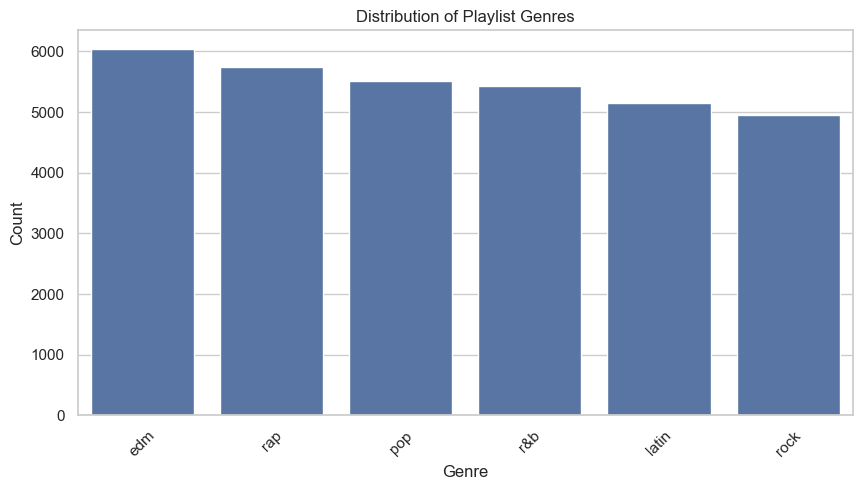

In [13]:
if "playlist_genre" in df.columns:
    plt.figure(figsize=(10, 5))
    genre_counts = df["playlist_genre"].value_counts()
    sns.barplot(x=genre_counts.index, y=genre_counts.values)
    plt.title("Distribution of Playlist Genres")
    plt.xlabel("Genre")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

The distribution of genres is not perfectly balanced, with some categories appearing much more frequently than others. This imbalance can affect classification performance and reinforces the need for appropriate evaluation metrics such as macro F1.

## 1.4 POPULARITY DISTRIBUTION

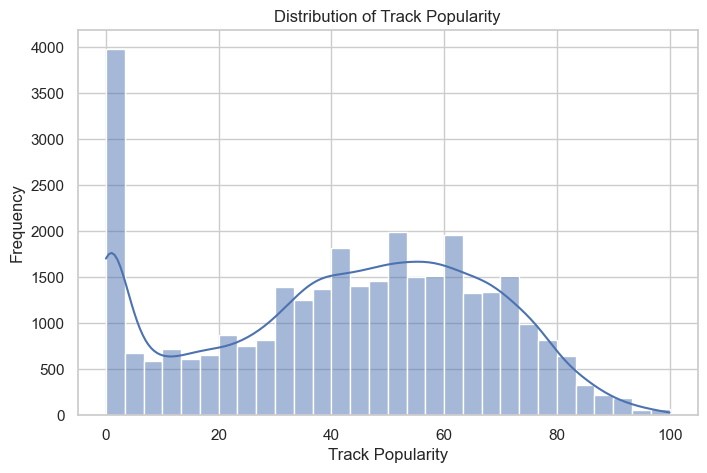

In [15]:
if "track_popularity" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df["track_popularity"], bins=30, kde=True)
    plt.title("Distribution of Track Popularity")
    plt.xlabel("Track Popularity")
    plt.ylabel("Frequency")
    plt.show()

Once again, the popularity distribution spans the full 0–100 range, although the dataset contains a noticeable concentration of tracks with very low popularity scores near zero. This likely reflects the presence of niche, older, or less commercially visible songs alongside mainstream releases.

Outside of this initial spike, the distribution is relatively broad and continuous, with many tracks concentrated between popularity values of roughly 35 and 70. This indicates that the dataset captures a mixture of moderately successful and highly streamed music rather than focusing exclusively on viral hits.

The absence of extreme imbalance across the remaining range supports transforming popularity into quantile-based categories for classification tasks. Instead of attempting to predict an exact popularity score, the project focuses on distinguishing broader popularity levels (low, medium, high), which is more stable and interpretable given the noisy and socially influenced nature of musical success.

## 1.5 AUDIO FEATURES DISTRIBUTION

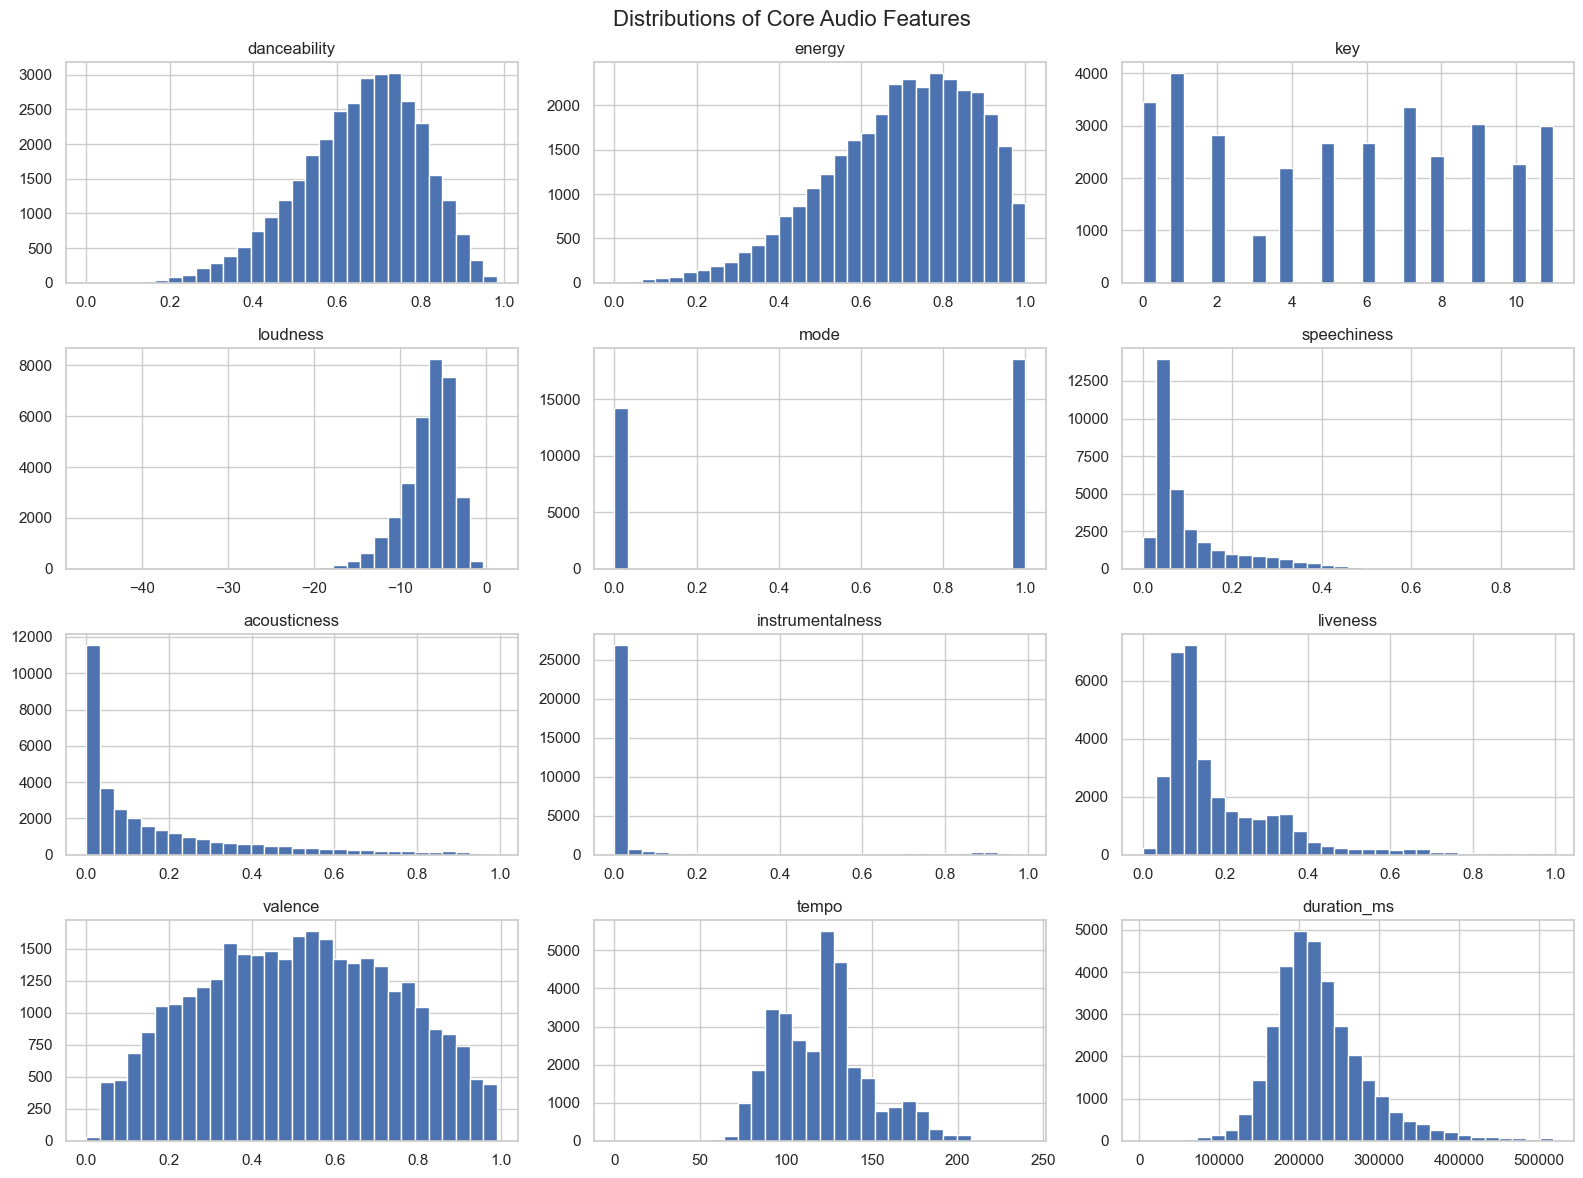

In [17]:
audio_features = [
    "danceability", "energy", "key", "loudness", "mode", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence",
    "tempo", "duration_ms"]

audio_features = [col for col in audio_features if col in df.columns]

df[audio_features].hist(figsize=(16, 12), bins=30)
plt.suptitle("Distributions of Core Audio Features", fontsize=16)
plt.tight_layout()
plt.show()

The distributions of audio features vary across variables, with some showing skewness or concentration around specific values. Different features may carry different levels of information and may require scaling or transformation.

## 1.6 CORRELATION HEATMAP

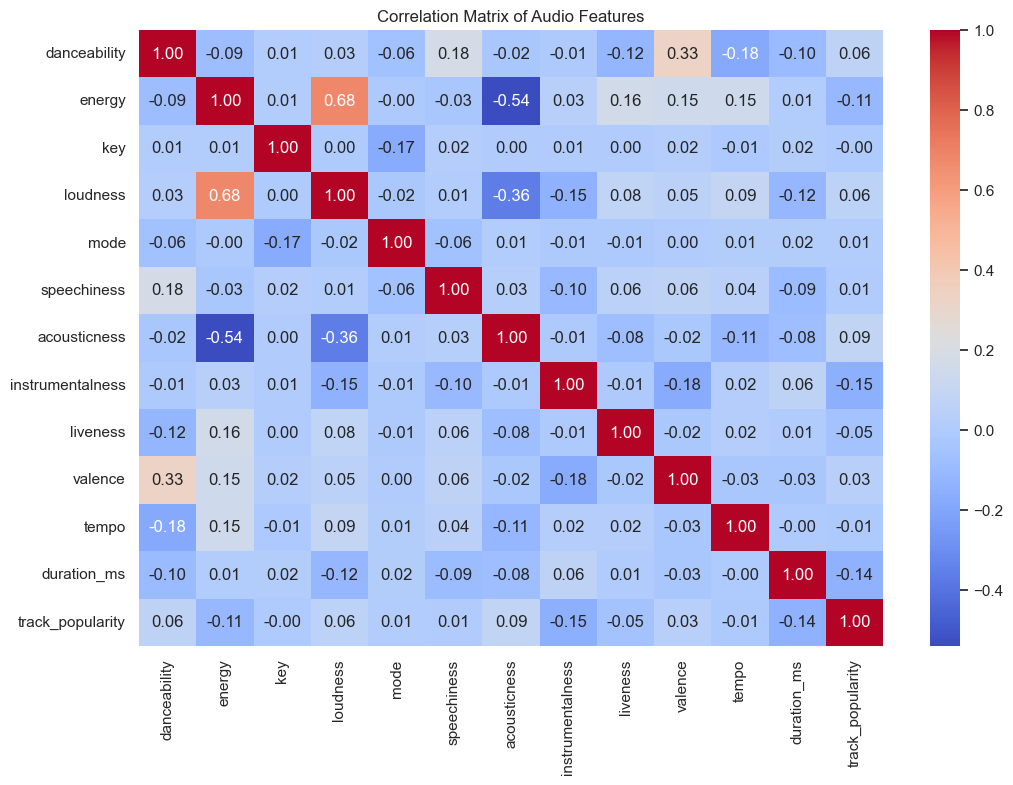

In [19]:
plt.figure(figsize=(12, 8))
corr_matrix = df[audio_features + (["track_popularity"] if "track_popularity" in df.columns else [])].corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Audio Features")
plt.show()

The correlation heatmap reveals that most individual audio features have relatively weak linear relationships with track popularity. This suggests that popularity is not determined by a single dominant musical characteristic, but rather by a combination of multiple subtle factors together with external influences not captured in the dataset.

Some stronger relationships do emerge between the audio variables themselves. For example, energy and loudness show a strong positive correlation, which is expected since louder songs are often perceived as more energetic. In contrast, acousticness is negatively correlated with both energy and loudness, reflecting the distinction between softer acoustic tracks and highly produced electronic or amplified music.

Danceability and valence also display a moderate positive relationship, indicating that more dance-oriented tracks tend to be associated with more positive or upbeat emotional tones.

Overall, the matrix suggests that Spotify audio features encode meaningful musical structure, even if they are not sufficient on their own to fully explain commercial success. These relationships become especially important later in the project during clustering and dimensionality reduction, where patterns emerge from combinations of features rather than isolated variables.

## 1.7 ARTIST AND TRACK FREQUENCY

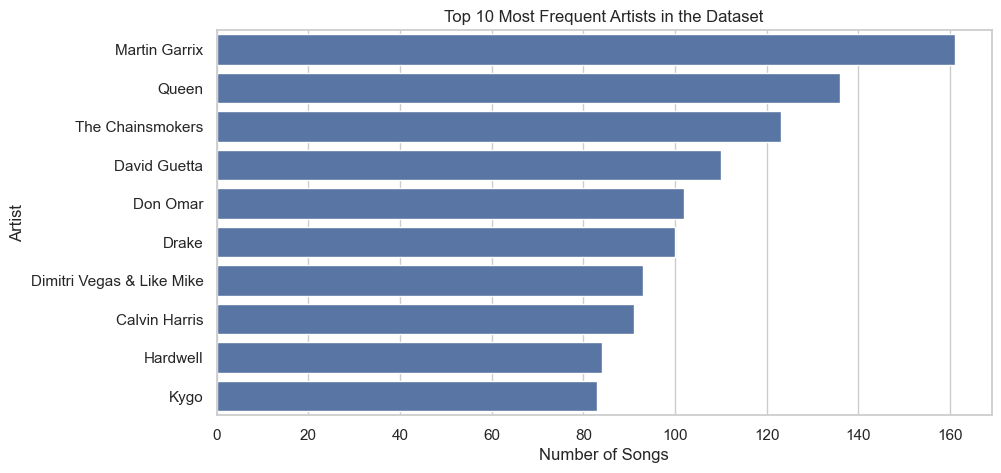


Number of tracks appearing more than once: 3166


track_id
7BKLCZ1jbUBVqRi2FVlTVw    10
3eekarcy7kvN4yt5ZFzltW     9
14sOS5L36385FJ3OL8hew4     9
7LzouaWGFCy4tkXDOOnEyM     8
2b8fOow8UzyDFAE27YhOZM     8
0sf12qNH5qcw8qpgymFOqD     8
0qaWEvPkts34WF68r8Dzx9     8
2Fxmhks0bxGSBdJ92vM42m     8
6oJ6le65B3SEqPwMRNXWjY     8
6Gg1gjgKi2AK4e0qzsR7sd     8
Name: count, dtype: int64

In [21]:
# REPEATED ARTISTS

if "track_artist" in df.columns:
    top_artists = df["track_artist"].value_counts().head(10)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=top_artists.values, y=top_artists.index)
    plt.title("Top 10 Most Frequent Artists in the Dataset")
    plt.xlabel("Number of Songs")
    plt.ylabel("Artist")
    plt.show()

# REPEATED TRACKS

if "track_id" in df.columns:
    repeated_track_counts = df["track_id"].value_counts() # If we count by track name instead of ID, we also get different counts because different songs have the same names
    repeated_tracks = repeated_track_counts[repeated_track_counts > 1]
    print(f"\nNumber of tracks appearing more than once: {repeated_tracks.shape[0]}")
    display(repeated_tracks.head(10))

The artist frequency distribution shows that certain artists appear substantially more often than others within the dataset. Artists such as Martin Garrix, David Guetta, and The Chainsmokers are heavily represented, reflecting the playlist-oriented nature of the collection and the strong presence of commercially successful electronic and pop music. At the same time, the dataset still contains a large number of unique artists and tracks overall, meaning that the analysis is not restricted to only a small group of mainstream performers.

We also observe that many songs appear multiple times across different playlists, with more than 3,000 tracks repeated at least once. These repetitions are not treated as traditional duplicate rows, since the same song may exist in different playlist contexts, genres, or recommendation environments.

This observation is important because it reflects how streaming platforms organize music in practice. Songs are not isolated entities; they circulate through multiple playlists, moods, and listening scenarios simultaneously. However, this also means that the dataset is not fully independent at the track level, which may slightly amplify the influence of particularly popular or frequently recommended songs during modeling.

## 1.8 HANDLING MISSING AND DUPLICATE VALUES

We begin the data preparation process by handling missing values. Since the dataset contains only a very small number of missing observations, we choose to remove these rows entirely. Given the size of the dataset, this has a negligible impact on the analysis while ensuring data consistency and avoiding the need for imputation.

In [23]:
# Count missing values per column
missing_counts = df.isnull().sum()

# Show only columns with missing values
missing_counts = missing_counts[missing_counts > 0]

print("Missing values per column:")
print(missing_counts)

# Total missing values
print("\nTotal missing values:", df.isnull().sum().sum())

Missing values per column:
track_name          5
track_artist        5
track_album_name    5
dtype: int64

Total missing values: 15


In [24]:
# Handle missing values by dropping rows with any missing entries
df_clean = df.dropna()

print("Original shape:", df.shape)
print("Shape after removing missing values:", df_clean.shape)

# Verify no missing values remain
print("Remaining missing values:", df_clean.isnull().sum().sum())

Original shape: (32833, 23)
Shape after removing missing values: (32828, 23)
Remaining missing values: 0


In [25]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


The next step would be to remove full duplicates but since we already found that there are none, and we don't intend to remove the songs that are the same but are in different playlists, we will skip this part.

After cleaning the dataset, we select only the relevant columns required for the analysis. This includes textual information, target variables, and core audio features. Removing unnecessary columns simplifies the dataset and ensures that subsequent modeling steps remain focused and efficient

## 1.9 COLUMN DEFINITION

In [27]:
# Define relevant columns for the project
columns_to_keep = [
    "track_name",
    "playlist_name",
    "playlist_genre",
    "playlist_subgenre",
    "track_popularity",
    "track_artist",
    "track_album_name",
    "danceability", "energy", "key", "loudness", "mode",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "duration_ms"
]

# Keep only selected columns
df_clean = df_clean[columns_to_keep]

print("Final dataset shape:", df_clean.shape)
display(df_clean.head())

Final dataset shape: (32828, 19)


,track_name,playlist_name,playlist_genre,playlist_subgenre,track_popularity,track_artist,track_album_name,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,I Don't Care (with Justin Bieber) - Loud Luxur...,Pop Remix,pop,dance pop,66,Ed Sheeran,I Don't Care (with Justin Bieber) [Loud Luxury...,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,Memories - Dillon Francis Remix,Pop Remix,pop,dance pop,67,Maroon 5,Memories (Dillon Francis Remix),0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,All the Time - Don Diablo Remix,Pop Remix,pop,dance pop,70,Zara Larsson,All the Time (Don Diablo Remix),0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,Call You Mine - Keanu Silva Remix,Pop Remix,pop,dance pop,60,The Chainsmokers,Call You Mine - The Remixes,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,Someone You Loved - Future Humans Remix,Pop Remix,pop,dance pop,69,Lewis Capaldi,Someone You Loved (Future Humans Remix),0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


---

# **2. TASK-SPECIFIC PIPELINES**

## **A. MUSIC AS LANGUAGE WITH 21 BY ADELE** → TEXT-BASED MODELING

## A.1 PROBLEM DEFINITION AND TARGET VARIABLES

Some albums become iconic not only because of how they sound, but because of how they communicate emotion, identity, and narrative. Adele’s *21* is one of the clearest examples of this idea: an album whose impact was driven as much by lyrical intimacy and emotional clarity as by production itself.

Inspired by this perspective, the first block explores whether textual information surrounding music contains meaningful musical structure.

We formulate this task as a supervised classification problem in which textual representations derived from track names and playlist titles are used to predict a target variable such as genre or popularity class. Rather than focusing exclusively on predictive performance, the objective is to evaluate whether language itself captures identifiable patterns in music.

Genre is used as the primary target because it provides a relatively direct representation of musical structure. Unlike popularity, which is influenced by external factors such as marketing, recommendation systems, and social media exposure, genre is more closely tied to stylistic and cultural characteristics within the music itself. This allows us to first test whether textual information contains meaningful musical signals before examining more complex outcomes such as commercial success. The same pipeline is later extended to popularity prediction. The main difference lies in the target definition: genre is already categorical, while popularity must first be transformed into balanced classes through quantile binning.

To represent text numerically, we use two complementary approaches:

- The first is **TF-IDF vectorization**, which converts words into weighted feature representations based on their importance across the corpus. This representation captures word frequency patterns and provides a sparse but highly interpretable representation of the text.
- The second approach uses **pretrained sentence embeddings**, which generate dense semantic representations capable of capturing contextual relationships between words and phrases. Unlike TF-IDF, embeddings allow the model to recognize semantic similarity even when different vocabulary is used.

By comparing these representations, we evaluate whether simple lexical patterns are sufficient to capture musical structure, or whether deeper semantic information improves performance. Finally, we compare both linear and non-linear models in order to evaluate not only whether textual information is predictive, but also whether the relationships captured in the text are relatively simple or require more complex decision boundaries.

## A.2 TEXT CONSTRUCTION AND PREPROCESSING

A textual feature is constructed by combining track names and playlist names into a single representation. This allows the model to capture patterns across both sources of textual information. Basic preprocessing ensures consistency and removes missing values.

NOTE: Including artist names can introduce proxy signal, allowing the model to learn popularity or genre from identity rather than musical structure. For a cleaner analysis, it is better to exclude artist or use it only as a comparison to highlight its impact.

In [32]:
# Create block-specific dataset
df_text = df_clean.copy()

# Combine text fields
df_text["text"] = df_text["track_name"] + df_text["playlist_name"]

display(df_text[["text"]].head())

# Target 1: Genre
y_genre = df_text["playlist_genre"]

# Target 2: Popularity (convert to categories)
df_text["popularity_class"] = pd.qcut(
    df_text["track_popularity"],
    q=3,
    labels=["low", "medium", "high"]
)

y_pop = df_text["popularity_class"]

# Check distributions
print("Genre distribution:")
print(y_genre.value_counts())

print("\nPopularity distribution:")
print(y_pop.value_counts())

,text
0,I Don't Care (with Justin Bieber) - Loud Luxur...
1,Memories - Dillon Francis RemixPop Remix
2,All the Time - Don Diablo RemixPop Remix
3,Call You Mine - Keanu Silva RemixPop Remix
4,Someone You Loved - Future Humans RemixPop Remix


Genre distribution:
playlist_genre
edm      6043
rap      5743
pop      5507
r&b      5431
latin    5153
rock     4951
Name: count, dtype: int64

Popularity distribution:
popularity_class
medium    11348
low       11054
high      10426
Name: count, dtype: int64


## A.3 FEATURE REPRESENTATION (TF-IDF)

Text is transformed into numerical features using TF-IDF, which captures the importance of words relative to the entire corpus. This representation allows machine learning models to process textual information effectively.

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_text = vectorizer.fit_transform(df_text["text"])

print("TF-IDF shape:", X_text.shape)

TF-IDF shape: (32828, 5000)


The resulting matrix has shape `(32828, 5000)`, meaning that the corpus is represented using the 5,000 most informative terms across 32,828 observations. This creates a high-dimensional representation capable of capturing lexical patterns associated with genres, moods, and listening contexts. Because most songs only contain a small subset of all possible words, the matrix is highly sparse. This sparsity is typical in natural language processing tasks and is one of the reasons why linear models such as Logistic Regression often perform well with TF-IDF representations.

## A.4 TRAIN-TEST SPLIT

The dataset is divided into training and test sets using stratified sampling in order to preserve the original class distributions across both targets. This ensures that genre and popularity categories remain balanced during evaluation and reduces the risk of biased performance estimates.

In [36]:
# Split for genre
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(
    X_text, y_genre,
    test_size=0.2,
    random_state=42,
    stratify=y_genre
)

# Split for popularity
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_text, y_pop,
    test_size=0.2,
    random_state=42,
    stratify=y_pop
)

An 80/20 split is used rather than a separate training-validation-test division because several models in the project already incorporate cross-validation during hyperparameter tuning. In these cases, the training data is internally subdivided multiple times during GridSearchCV, allowing the models to be validated without requiring an additional fixed validation set. This approach improves methodological consistency while also preserving more data for training. Furthermore, the test set remains completely unseen during training and tuning, providing a fair final evaluation of model performance.

## A.6 BASELINE MODEL: LOGISTIC REGRESSION

Logistic Regression is used as the baseline model for the text-based pipeline. As a linear classifier, it provides a useful reference point for evaluating whether textual representations already contain separable patterns without requiring complex non-linear architectures. The model learns weighted relationships between words and target categories, allowing us to test whether relatively simple linear decision boundaries are sufficient to capture musical structure from text alone.

In [38]:
log_reg = LogisticRegression(max_iter=1000)

# GENRE
log_reg.fit(X_train_g, y_train_g)
y_pred_lr_g = log_reg.predict(X_test_g)

print("Logistic Regression (Genre)")
print("Accuracy:", accuracy_score(y_test_g, y_pred_lr_g))
print("Macro F1:", f1_score(y_test_g, y_pred_lr_g, average="macro"))

# POPULARITY
log_reg.fit(X_train_p, y_train_p)
y_pred_lr_p = log_reg.predict(X_test_p)

print("\nLogistic Regression (Popularity)")
print("Accuracy:", accuracy_score(y_test_p, y_pred_lr_p))
print("Macro F1:", f1_score(y_test_p, y_pred_lr_p, average="macro"))

Logistic Regression (Genre)
Accuracy: 0.929332927200731
Macro F1: 0.929819523937574

Logistic Regression (Popularity)
Accuracy: 0.5604629911666159
Macro F1: 0.5612619009722173


The baseline model achieves very strong performance for genre classification, reaching approximately **93% accuracy and macro F1-score**. This indicates that textual information such as track names and playlist titles contains highly structured signals associated with musical genres. Even a relatively simple linear model is capable of separating genres effectively from text alone.

Performance is noticeably lower for popularity prediction, with scores around **56% macro F1**. While this still exceeds random guessing, the weaker performance suggests that popularity is substantially more difficult to infer from textual information alone. Unlike genre, which reflects stylistic structure, popularity is influenced by many external factors including recommendation systems, marketing exposure, cultural trends, and listener behavior.

**The contrast between both tasks already supports one of the central hypotheses of the project: musical identity appears far more structurally predictable than commercial success.**

## A.7 FEED FORWARD NEURAL NETWORK (MLP)

A Multilayer Perceptron (MLP), a type of feedforward neural network, is used to model non-linear relationships in the textual feature space. In this architecture, information flows from input to output through one or more hidden layers, where each neuron computes a weighted sum of inputs followed by a non-linear activation function. This structure allows the model to approximate complex functions and capture interactions between features.

To ensure a principled model selection process, hyperparameter tuning is performed using a grid search strategy combined with cross-validation. A small set of candidate architectures, activation functions, and regularization strengths is evaluated. The best configuration is selected based on macro F1-score, which ensures balanced performance across classes. The final model is then evaluated on the test set and compared to the baseline model to determine whether non-linear modeling improves performance.

In some cases, transformers (such as BERT) would be useful in detecting text characteristics, but we decided against it, as our text is more on the short end and transformers require many setups (tokens, parameters, etc) and it won't shine much when faced with our FFN.

In [40]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

le_g = LabelEncoder()
y_train_g_enc = le_g.fit_transform(y_train_g)
y_test_g_enc = le_g.transform(y_test_g)

mlp = MLPClassifier(
        max_iter=80,
        random_state=42,
        early_stopping=True,
        n_iter_no_change=5,
        tol=1e-3
)

param_grid = {
    "hidden_layer_sizes": [(64,), (128,), (128, 64)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001]
}

grid_search_g = GridSearchCV(
    mlp,
    param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=4,
    verbose=2
)

grid_search_g.fit(X_train_g, y_train_g_enc)

best_mlp_g = grid_search_g.best_estimator_
y_pred_mlp_g = best_mlp_g.predict(X_test_g)

print("Best parameters (Genre):", grid_search_g.best_params_)
print("Accuracy:", accuracy_score(y_test_g_enc, y_pred_mlp_g))
print("Macro F1:", f1_score(y_test_g_enc, y_pred_mlp_g, average="macro"))

# ----------

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV

le_p = LabelEncoder()
y_train_p_enc = le_p.fit_transform(y_train_p)
y_test_p_enc = le_p.transform(y_test_p)

grid_search_p = GridSearchCV(
    mlp,
    param_grid,
    scoring="f1_macro",
    cv=3,
    n_jobs=4,
    verbose=2
)

grid_search_p.fit(X_train_p, y_train_p_enc)

best_mlp_p = grid_search_p.best_estimator_
y_pred_mlp_p = best_mlp_p.predict(X_test_p)

print("Best parameters (Popularity):", grid_search_p.best_params_)

print("Tuned MLP (Popularity)")
print("Accuracy:", accuracy_score(y_test_p_enc, y_pred_mlp_p))
print("Macro F1:", f1_score(y_test_p_enc, y_pred_mlp_p, average="macro"))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters (Genre): {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (128,)}
Accuracy: 0.9278099299421261
Macro F1: 0.9284454226570878
Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters (Popularity): {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (128, 64)}
Tuned MLP (Popularity)
Accuracy: 0.5539141029546146
Macro F1: 0.5524160563497603


The tuned MLP achieves performance very similar to the Logistic Regression baseline for genre classification, reaching approximately **93% accuracy and macro F1-score**. This suggests that the textual signal associated with genre is already highly separable using relatively simple linear relationships, meaning that additional model complexity provides only marginal improvements.

For popularity prediction, the MLP again performs only moderately, with results remaining close to the baseline model. Despite the neural network’s ability to capture non-linear interactions, the improvement is limited, reinforcing the idea that popularity is not strongly determined by textual information alone.

**An important observation is that increasing model complexity does not fundamentally change the conclusions of the block.** Textual information clearly captures musical identity and genre-related structure, but it remains substantially less effective at explaining commercial success.

## A.8 PRETRAINED TEXT REPRESENTATION (EMBEDDINGS)

In addition to TF-IDF representations, we extend our analysis using pretrained language models. Unlike TF-IDF, which relies on word frequency, pretrained models capture semantic relationships between words and phrases.

We use a Sentence Transformer model to generate dense vector embeddings of the text. These embeddings encode contextual meaning, allowing the model to recognize similarities between semantically related phrases. This approach is included as an extension to evaluate whether more expressive representations improve predictive performance.

*Warning: Embedding-based experiments were originally executed using the package versions listed in the following code. Due to dependency compatibility issues between PyTorch, Transformers, and Python environments, we decided to manually introduce the output from our final test run, instead of risking a compatibility error in another environment*


In [42]:
# Set-up (Python 3.13):
# !pip install "sentence-transformers==2.2.2" "transformers==4.36.2"
# from sentence_transformers import SentenceTransformer

# Load pretrained model
# embed_model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings
# X_embed = embed_model.encode(
    # df_text["text"].tolist(),
    # show_progress_bar=True
# )

# print("Embedding shape:", X_embed.shape)

In [43]:
# TRAIN SIMPLE CLASSIFIER

# GENRE
# embed_model_g = LogisticRegression(max_iter=1000)
# embed_model_g.fit(X_train_g, y_train_g)
# y_pred_g = embed_model_g.predict(X_test_g)

# print("\nEmbedding Model (Genre)")
# print("Accuracy:", accuracy_score(y_test_g, y_pred_g))
# print("Macro F1:", f1_score(y_test_g, y_pred_g, average="macro"))


# POPULARITY
# embed_model_p = LogisticRegression(max_iter=1000)
# embed_model_p.fit(X_train_p, y_train_p)
# y_pred_p = embed_model_p.predict(X_test_p)

# print("\nEmbedding Model (Popularity)")
# print("Accuracy:", accuracy_score(y_test_p, y_pred_p))
# print("Macro F1:", f1_score(y_test_p, y_pred_p, average="macro"))

```text
Embedding Model (Genre)
Accuracy: 0.8845568077977459
Macro F1: 0.884796793082133

Embedding Model (Popularity)
Accuracy: 0.5140115747791654
Macro F1: 0.513652113167522
```



The embedding-based model achieves strong performance for genre classification, reaching approximately **88% accuracy and macro F1-score**. Although slightly lower than the TF-IDF representation, the results still confirm that semantic information contained in text carries substantial musical structure.

For popularity prediction, performance remains relatively limited, with scores near **51% macro F1**. Even with richer semantic representations, the model struggles to infer commercial success reliably from textual information alone.

An interesting result is that the simpler TF-IDF representation slightly outperforms the pretrained embeddings in both tasks. This suggests that genre and playlist patterns in this dataset are driven more by direct lexical associations and recurring keywords than by deeper semantic relationships. In other words, explicit genre-related vocabulary appears to be more informative than contextual language understanding for this particular problem.

## A.9 EVALUATION METRICS

All models are evaluated using accuracy and macro F1-score, ensuring consistent and fair comparison across different feature representations and model types. The embedding-based model is evaluated alongside TF-IDF-based models to assess whether semantic representations improve performance.

*Warning: The embedding metrics will appear after the others, as we have input them manually*

In [46]:
print("\n================ GENRE MODELS ================")

print("\nGenre Report (Logistic - TFIDF)")
print(classification_report(y_test_g, y_pred_lr_g))

print("\nGenre Report (MLP - TFIDF)")
print(classification_report(y_test_g_enc, y_pred_mlp_g))

# print("\nGenre Report (Embeddings)")
# print(classification_report(y_test_e_g, y_pred_e_g))


print("\n================ POPULARITY MODELS ================")

print("\nPopularity Report (Logistic - TFIDF)")
print(classification_report(y_test_p, y_pred_lr_p))

print("\nPopularity Report (MLP - TFIDF)")
print(classification_report(y_test_p_enc, y_pred_mlp_p))

# print("\nPopularity Report (Embeddings)")
# print(classification_report(y_test_e_p, y_pred_e_p))


================ GENRE MODELS ================

Genre Report (Logistic - TFIDF)
              precision    recall  f1-score   support

         edm       0.96      0.93      0.95      1209
       latin       0.89      0.92      0.91      1031
         pop       0.91      0.94      0.93      1101
         r&b       0.91      0.90      0.91      1086
         rap       0.92      0.90      0.91      1149
        rock       0.98      0.99      0.98       990

    accuracy                           0.93      6566
   macro avg       0.93      0.93      0.93      6566
weighted avg       0.93      0.93      0.93      6566


Genre Report (MLP - TFIDF)
              precision    recall  f1-score   support

           0       0.96      0.93      0.94      1209
           1       0.92      0.91      0.92      1031
           2       0.91      0.93      0.92      1101
           3       0.91      0.90      0.90      1086
           4       0.90      0.92      0.91      1149
           5       0.98

```text
================ GENRE MODELS ================

Genre Report (Embeddings)

              precision    recall    f1-score    support

edm              0.89       0.90       0.89       1209
latin            0.86       0.83       0.84       1031
pop              0.88       0.88       0.88       1101
r&b              0.85       0.84       0.85       1086
rap              0.88       0.90       0.89       1149
rock             0.95       0.95       0.95        990

accuracy                                 0.88      6566
macro avg         0.89       0.88       0.88      6566
weighted avg      0.88       0.88       0.88      6566


================ POPULARITY MODELS ================

Popularity Report (Embeddings)

              precision    recall    f1-score    support

high             0.55       0.56       0.55       2085
low              0.53       0.57       0.55       2211
medium           0.47       0.42       0.44       2270

accuracy                                 0.51      6566
macro avg         0.51       0.52       0.51      6566
weighted avg      0.51       0.51       0.51      6566
```

*Note: Unlike Block B, no explicit baseline classifier was introduced in Block A. This decision was made to keep the focus on comparing textual representations and model behavior rather than expanding the number of benchmark models unnecessarily.m However, the expected naive baseline performance can still be inferred from the class structure itself. Since the genre task contains six relatively balanced classes, random or majority-class performance would remain close to approximately 0.17 accuracy/F1. Similarly, the popularity task uses three balanced quantile-based categories, implying a naive baseline near 0.33. Moreover, both are outperformed by all of the designed models.*

The results of Block A strongly suggest that textual information surrounding music contains meaningful and highly structured signals related to musical identity. Even before analyzing audio itself, models are capable of recovering genres with remarkably high accuracy using only track names and playlist titles.

**This finding supports one of the central ideas of the project: music is not represented only through sound, but also through language, context, and cultural framing.**

### Main Observations

- **Genre classification consistently achieved very high performance across all models**, with TF-IDF representations reaching approximately **93% macro F1-score**. This indicates that genres leave strong linguistic traces inside playlist names, track titles, and surrounding textual metadata.

- **Popularity prediction was substantially more difficult**, with performance remaining around **51–56% macro F1-score** depending on the representation and model used. While the models performed above random guessing, the predictive signal was noticeably weaker than for genre classification.

- **TF-IDF representations outperformed pretrained embeddings** in both tasks. Although embeddings capture richer semantic relationships, the dataset appears to rely heavily on explicit lexical patterns and recurring genre-related vocabulary. In this context, direct word associations were more informative than deeper contextual meaning.

- **Increasing model complexity produced only marginal improvements.** Logistic Regression performed almost identically to the tuned neural network for genre prediction, suggesting that the textual structure of genres is already highly separable through relatively simple linear boundaries.

### Interpreting the Genre Results

The genre results reveal that musical categories are deeply embedded in the language surrounding music. Playlist names often contain explicit stylistic references, moods, listening contexts, or cultural associations that strongly correlate with genres.

For example, words associated with nightlife, remixes, festivals, or electronic culture frequently appear in EDM-related playlists, while other genres develop their own recognizable textual ecosystems. In many ways, the models are not only learning music. They are learning how people talk about music.

This is precisely why *21* by Adele serves as the conceptual inspiration for this block. Songs such as *Rolling in the Deep*, *Someone Like You*, or *Set Fire to the Rain* became iconic not because they depended on algorithmic optimization or viral structures, but because they carried emotional clarity and narrative identity. Even years later, their titles alone immediately evoke a specific emotional atmosphere.

The models capture a simplified computational version of this phenomenon: language itself carries musical identity.

### Interpreting the Popularity Results

The popularity results tell a very different story. Unlike genre, popularity is not purely a structural property of music. Commercial success depends on many external variables that are absent from the dataset, including:
- Marketing and promotion
- Playlist placement
- Recommendation algorithms
- Artist reputation
- Social media exposure
- Cultural timing
- Audience behavior

As a result, textual information alone is insufficient to explain why certain songs become massively successful while others remain relatively niche. This limitation is important because it prevents the project from reducing music entirely to optimization. The models can recover musical identity quite effectively, but success itself remains only partially predictable.

**In other words, the data captures what music *is* more easily than why music *wins*.**

### Broader Implications

Block A ultimately demonstrates that modern music platforms contain highly structured linguistic ecosystems. Titles, playlist labels, and semantic descriptions are not random metadata; they encode recognizable musical patterns that machine learning models can learn surprisingly well. At the same time, the weaker popularity results highlight the limits of purely data-driven explanations of musical success. Even in highly algorithmic streaming environments, commercial performance still depends on human, cultural, and contextual factors that extend beyond the textual representation itself.

This contrast between strong genre predictability and moderate popularity predictability becomes one of the central themes of the entire project and motivates the transition toward the next analytical block: understanding whether success can be better explained through audio structure and combined feature representations.

## **B. MUSIC AS SUCCESS WITH THRILLER BY MICHAEL JACKSON** → POPULARITY PREDICTION

## B.1 PROBLEM DEFINITION

Some albums define not only an artist, but an entire era of popular culture. Released in 1982, Michael Jackson’s *Thriller* became one of the most commercially successful albums in history, transforming music into a global multimedia phenomenon. Its success was not driven by a single factor, but by the combination of musical production, performance, branding, timing, and cultural impact. In the streaming era, however, success operates differently.

Popularity is no longer determined only by radio stations, television appearances, or physical sales. Modern platforms reward replayability, algorithmic visibility, playlist placement, and audience retention. Songs compete not only for artistic recognition, but for attention inside recommendation systems and highly saturated digital environments.

This raises a central question for the project:

> can commercial success actually be predicted from the characteristics of the music itself?

Unlike genre classification, popularity is not a purely musical label. A song may become successful because of social media exposure, artist reputation, marketing strategies, or cultural trends that are completely absent from the dataset. Nevertheless, Spotify audio features and textual metadata may still contain partial signals associated with successful tracks.

For this reason, Block B investigates popularity prediction as a supervised classification problem. Rather than predicting an exact popularity score, the task focuses on distinguishing broader popularity levels (low, medium, and high) using different musical representations.

The objective of this block is not simply to maximize accuracy, but to explore how much of commercial success is structurally learnable from data, and how much remains outside the reach of machine learning models.

## B.2 TARGET VARIABLE CONSTRUCTION

The original popularity variable is continuous, ranging from 0 to 100. To make it suitable for classification, we discretize it into three categories using quantile binning. This ensures balanced classes and allows fair evaluation across groups.

Rather than treating popularity as a continuous regression target, we transform it into categorical groups in order to simplify interpretation and create a more stable classification framework. This allows the models to focus on distinguishing broader levels of commercial success rather than predicting highly noisy exact popularity values.

Quantile-based binning is used because popularity scores in streaming platforms are not uniformly distributed. By dividing the dataset into equally sized groups, we reduce class imbalance and ensure that each popularity category contributes similarly during training and evaluation.

In [51]:
# Create block-specific dataset
df_pop = df_clean.copy()

df_pop["popularity_class"] = pd.qcut(
    df_pop["track_popularity"],
    q=3,
    labels=["low", "medium", "high"]
)

print("Class distribution:")
print(df_pop["popularity_class"].value_counts())

print("\nClass distribution (%):")
print(df_pop["popularity_class"].value_counts(normalize=True) * 100)

Class distribution:
popularity_class
medium    11348
low       11054
high      10426
Name: count, dtype: int64

Class distribution (%):
popularity_class
medium    34.568052
low       33.672475
high      31.759474
Name: proportion, dtype: float64


The classes are well-balanced, which ensures that the model does not favor one class over others and that macro F1-score is meaningful.

The resulting class distribution is highly balanced, with each category representing roughly one third of the dataset. This is important because it prevents the models from artificially favoring one popularity group over another and makes macro F1-score a more reliable evaluation metric.

Conceptually, this transformation also reflects the main objective of the block. In real-world music consumption, the difference between a song with popularity 61 and 63 is often less meaningful than the distinction between relatively unknown tracks and highly visible mainstream songs. The classification setup therefore captures broader commercial tiers rather than attempting to model exact popularity values.

## B.3 FEATURE DEFINITION

To evaluate how different representations of music contribute to popularity prediction, we construct three separate feature spaces:
- Audio features (numerical)
- Text features (TF-IDF)
- Combined features (audio + text)

This comparison is important because audio features describe the intrinsic musical properties of a song, while textual information reflects external context such as artist identity, playlist culture, branding, and listener framing. By evaluating these representations independently and together, we can examine whether commercial success is driven more strongly by the sound of the music itself or by the ecosystem surrounding it.

Some textual variables may also introduce indirect popularity signals. For example, artist names or playlist titles can encode cultural visibility and recommendation bias. Rather than removing these effects entirely, we keep them intentionally and interpret the results as part of the broader streaming environment in which popularity emerges.

In [54]:
# AUDIO FEATURES
audio_features = [
    "danceability", "energy", "key", "loudness", "mode",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "duration_ms"
]

X_audio = df_pop[audio_features]

# TARGET
y = df_pop["popularity_class"]

# TEXT FEATURES (NOTE: includes metadata, so interpret carefully)
text_columns = [
    "track_name",
    "track_artist",
    "track_album_name",
    "playlist_name"
]

df_pop["text_data"] = df_pop[text_columns].astype(str).agg(" ".join, axis=1)


tfidf = TfidfVectorizer(
    max_features=3000,
    stop_words="english"
)

X_text = tfidf.fit_transform(df_pop["text_data"])

print("Audio feature shape:", X_audio.shape)
print("Text feature shape:", X_text.shape)

Audio feature shape: (32828, 12)
Text feature shape: (32828, 3000)


The resulting feature spaces differ substantially in dimensionality. The audio representation contains only 12 structured numerical variables, while the TF-IDF text representation expands into 3,000 sparse lexical features. This contrast reflects two fundamentally different ways of representing music. Audio features provide compact and interpretable descriptions of acoustic structure, whereas textual features encode much richer but more diffuse semantic information. The combined representation later allows us to test whether integrating both perspectives improves predictive performance, or whether one source of information dominates the prediction of popularity.

## B.4 TRAIN-TEST SPLIT

We perform a single stratified split to ensure fair comparison across all feature sets.

In [56]:
indices = np.arange(len(df_pop))

idx_train, idx_test, y_train, y_test = train_test_split(
    indices,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# AUDIO SPLIT
X_audio_train = X_audio.iloc[idx_train]
X_audio_test = X_audio.iloc[idx_test]

# TEXT SPLIT
X_text_train = X_text[idx_train]
X_text_test = X_text[idx_test]

Stratification ensures each class is equally represented in train and test sets.

## B.5 FEATURE SCALING AND COMBINATION

Before combining the feature spaces, the numerical audio variables are standardized using `StandardScaler`. Scaling is necessary because audio features operate on different numerical ranges. Without normalization, variables with larger magnitudes (such as tempo or duration) could dominate the learning process and disproportionately influence distance-based or optimization-based models. In contrast, the TF-IDF text representation is left unchanged because TF-IDF already performs internal normalization and produces appropriately scaled sparse vectors.

After scaling, the numerical audio features and sparse textual features are merged into a single combined representation. This hybrid feature space allows the models to simultaneously access intrinsic musical characteristics and contextual semantic information.

In [58]:
scaler = StandardScaler()

X_audio_train_scaled = scaler.fit_transform(X_audio_train)
X_audio_test_scaled = scaler.transform(X_audio_test)

print("Scaled audio train shape:", X_audio_train_scaled.shape)
print("Scaled audio test shape:", X_audio_test_scaled.shape)

# COMBINED FEATURES
X_combined_train = hstack([X_text_train, X_audio_train_scaled])
X_combined_test = hstack([X_text_test, X_audio_test_scaled])

print("Combined train shape:", X_combined_train.shape)
print("Combined test shape:", X_combined_test.shape)

Scaled audio train shape: (26262, 12)
Scaled audio test shape: (6566, 12)
Combined train shape: (26262, 3012)
Combined test shape: (6566, 3012)


The scaled audio representation preserves the original 12 numerical audio variables while standardizing their distributions around comparable ranges. The combined feature space expands to more than 3,000 dimensions by integrating both structured numerical information and sparse textual representations. This combined representation becomes particularly important later in the analysis because it allows us to evaluate whether popularity is better explained through the sound of the music itself, the surrounding textual context, or the interaction between both forms of information.

Conceptually, this step mirrors the modern streaming environment, where songs are consumed not only through audio, but also through playlists, metadata, artist identity, and recommendation ecosystems simultaneously.

## B.6 EVALUATION FRAMEWORK

Model performance is evaluated primarily using **accuracy** and **macro F1-score**. Accuracy measures the overall proportion of correct predictions, while macro F1-score gives equal importance to all classes by averaging performance independently across categories. Macro F1-score is particularly important in this project because it prevents strong performance on a single class from masking poor performance on others. This provides a more balanced evaluation of how well the models distinguish between different popularity levels.

n addition to the predictive models, we also introduce a simple baseline classifier that always predicts the most frequent class. This establishes a minimum performance reference and helps determine whether the learned models capture meaningful structure beyond naive guessing.

In [60]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, feature_set):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")

    print(f"Model: {model_name}")
    print(f"Feature set: {feature_set}")
    print("Accuracy:", round(accuracy, 4))
    print("Macro F1:", round(macro_f1, 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return {
        "Model": model_name,
        "Feature Set": feature_set,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    }

results = []

baseline = DummyClassifier(strategy="most_frequent")

results.append(
    evaluate_model(
        baseline,
        X_audio_train_scaled,
        X_audio_test_scaled,
        y_train,
        y_test,
        "Baseline - Most Frequent",
        "Audio"
    )
)

Model: Baseline - Most Frequent
Feature set: Audio
Accuracy: 0.3457
Macro F1: 0.1713

Classification Report:
              precision    recall  f1-score   support

        high       0.00      0.00      0.00      2085
         low       0.00      0.00      0.00      2211
      medium       0.35      1.00      0.51      2270

    accuracy                           0.35      6566
   macro avg       0.12      0.33      0.17      6566
weighted avg       0.12      0.35      0.18      6566

Confusion Matrix:
[[   0    0 2085]
 [   0    0 2211]
 [   0    0 2270]]


The baseline model achieves approximately **35% accuracy**, which is close to random guessing across the three balanced popularity classes. As expected, the classifier predicts only the majority class (“medium”) and completely fails to distinguish low and high popularity songs. This result confirms that the popularity prediction task is non-trivial. Any meaningful improvement beyond the baseline indicates that the models are learning genuine patterns from the feature representations rather than exploiting class imbalance or random chance. Additionally, the very low macro F1-score further highlights the limitations of naive prediction strategies and justifies the need for more expressive models and richer feature representations in the following sections.

## B.7 AUDIO MODELS

To evaluate whether commercial success can be inferred directly from the sound of the music itself, we first train models using only Spotify audio features. These variables describe intrinsic musical properties such as energy, danceability, tempo, loudness, and acousticness, without incorporating contextual metadata or textual information.

Three different model families are compared:
- **Logistic Regression**, which provides a linear baseline
- **Random Forest**, which captures non-linear interactions through ensemble decision trees
- **Gradient Boosting**, which incrementally improves predictions by correcting previous errors

Comparing these models allows us to evaluate not only predictive performance, but also the complexity of the relationship between audio structure and popularity.

In [62]:
audio_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

for model_name, model in audio_models.items():
    results.append(
        evaluate_model(
            model,
            X_audio_train_scaled,
            X_audio_test_scaled,
            y_train,
            y_test,
            model_name,
            "Audio"
        )
    )

Model: Logistic Regression
Feature set: Audio
Accuracy: 0.4295
Macro F1: 0.4257

Classification Report:
              precision    recall  f1-score   support

        high       0.43      0.54      0.48      2085
         low       0.45      0.45      0.45      2211
      medium       0.40      0.31      0.35      2270

    accuracy                           0.43      6566
   macro avg       0.43      0.43      0.43      6566
weighted avg       0.43      0.43      0.42      6566

Confusion Matrix:
[[1128  488  469]
 [ 657  999  555]
 [ 840  737  693]]
Model: Random Forest
Feature set: Audio
Accuracy: 0.5433
Macro F1: 0.5454

Classification Report:
              precision    recall  f1-score   support

        high       0.63      0.62      0.63      2085
         low       0.52      0.50      0.51      2211
      medium       0.49      0.52      0.50      2270

    accuracy                           0.54      6566
   macro avg       0.55      0.54      0.55      6566
weighted avg      

The results show that audio features alone contain meaningful information related to popularity, but their predictive power remains moderate overall.

Among the evaluated models, **Random Forest achieves the strongest performance**, reaching approximately **55% macro F1-score**, substantially outperforming the linear Logistic Regression baseline. This suggests that the relationship between musical structure and popularity is not purely linear, and that interactions between audio features play an important role in determining commercial success. In contrast, Logistic Regression performs noticeably worse, indicating that individual audio variables are insufficient when considered through simple linear decision boundaries. Gradient Boosting also improves upon the baseline, but does not surpass Random Forest in this configuration.

Even so, the overall scores remain relatively modest compared to the genre classification results observed in Block A. This reinforces one of the central themes of the project: **while audio features encode identifiable musical structure, popularity itself is only partially explainable through intrinsic characteristics of the music.**

The confusion matrices further show that the models struggle particularly with the “medium” popularity category, which overlaps substantially with both low and high popularity songs. This overlap reflects the continuous and socially influenced nature of commercial success, where many songs occupy ambiguous positions between niche and mainstream visibility.

## B.8 TEXT MODELS

After evaluating audio-only representations, we now investigate whether textual metadata provides stronger predictive signals for popularity. Unlike audio features, textual information may capture contextual and cultural aspects of music consumption, including artist visibility, playlist framing, branding, and recommendation environments. Two models are evaluated on the TF-IDF text representation:

- **Logistic Regression**, which serves as a strong baseline for sparse textual data
- **Random Forest**, which captures non-linear interactions between lexical patterns

Gradient Boosting is not included in this section because boosting-based tree methods tend to perform less efficiently on extremely high-dimensional sparse matrices such as TF-IDF representations.

In [64]:
text_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

for model_name, model in text_models.items():
    results.append(
        evaluate_model(
            model,
            X_text_train,
            X_text_test,
            y_train,
            y_test,
            model_name,
            "Text"
        )
    )

Model: Logistic Regression
Feature set: Text
Accuracy: 0.6022
Macro F1: 0.6031

Classification Report:
              precision    recall  f1-score   support

        high       0.66      0.67      0.66      2085
         low       0.61      0.63      0.62      2211
      medium       0.54      0.51      0.53      2270

    accuracy                           0.60      6566
   macro avg       0.60      0.60      0.60      6566
weighted avg       0.60      0.60      0.60      6566

Confusion Matrix:
[[1404  242  439]
 [ 277 1385  549]
 [ 459  646 1165]]
Model: Random Forest
Feature set: Text
Accuracy: 0.6115
Macro F1: 0.6128

Classification Report:
              precision    recall  f1-score   support

        high       0.66      0.67      0.66      2085
         low       0.64      0.64      0.64      2211
      medium       0.54      0.53      0.54      2270

    accuracy                           0.61      6566
   macro avg       0.61      0.61      0.61      6566
weighted avg       0

The text-based models outperform the audio-only models across all evaluation metrics, with Random Forest achieving the strongest performance at approximately **61% macro F1-score**. This suggests that textual metadata contains richer predictive information about popularity than intrinsic audio characteristics alone. An important implication of this result is that popularity appears to be strongly connected to the contextual ecosystem surrounding music rather than purely to its acoustic structure. Playlist names, artist identities, and recurring genre-related vocabulary may indirectly encode visibility, branding, recommendation behavior, and audience perception.

The improvement of Random Forest over Logistic Regression again indicates that the relationship between textual patterns and popularity is not fully linear. Certain combinations of words, artists, or playlist contexts likely interact in complex ways when associated with commercially successful songs. At the same time, performance remains far from perfect. Even though text provides stronger signals than audio alone, the models still struggle to fully separate popularity categories, particularly the medium-popularity group. **This reinforces the broader conclusion that commercial success is only partially predictable from the information available in the dataset.**

## B.9 COMBINED MODELS

The final representation combines both audio and textual information into a single feature space. This allows the models to simultaneously access intrinsic musical characteristics together with contextual metadata such as playlist titles, artist identity, and lexical patterns. The objective of this section is to evaluate whether integrating multiple representations of music improves popularity prediction beyond what is achievable using audio or text independently.

As in the previous sections, **Logistic Regression** and **Random Forest** are used to compare linear and non-linear modeling behavior within the combined feature space.

In [66]:
combined_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

for model_name, model in combined_models.items():
    results.append(
        evaluate_model(
            model,
            X_combined_train,
            X_combined_test,
            y_train,
            y_test,
            model_name,
            "Combined"
        )
    )

Model: Logistic Regression
Feature set: Combined
Accuracy: 0.6068
Macro F1: 0.6076

Classification Report:
              precision    recall  f1-score   support

        high       0.66      0.68      0.67      2085
         low       0.62      0.63      0.62      2211
      medium       0.54      0.52      0.53      2270

    accuracy                           0.61      6566
   macro avg       0.61      0.61      0.61      6566
weighted avg       0.61      0.61      0.61      6566

Confusion Matrix:
[[1416  232  437]
 [ 271 1395  545]
 [ 457  640 1173]]
Model: Random Forest
Feature set: Combined
Accuracy: 0.6301
Macro F1: 0.6318

Classification Report:
              precision    recall  f1-score   support

        high       0.69      0.69      0.69      2085
         low       0.64      0.63      0.63      2211
      medium       0.57      0.57      0.57      2270

    accuracy                           0.63      6566
   macro avg       0.63      0.63      0.63      6566
weighted avg

The combined representation achieves the strongest overall performance in Block B, with Random Forest reaching approximately **63% macro F1-score**. This indicates that audio and textual information provide complementary signals when predicting popularity. However, the improvement over the text-only representation remains relatively small. This suggests that much of the predictive signal is already captured by the textual metadata, while the audio features contribute only moderate additional information.

In other words, how music is described, categorized, and contextualized within streaming platforms appears to be at least as important as the acoustic structure of the songs themselves when modeling commercial success. The superior performance of Random Forest once again highlights the presence of non-linear interactions between features. Popularity does not emerge from isolated variables, but from complex combinations of musical characteristics, metadata, and contextual associations. At the same time, the overall performance still remains far from perfect. Even after combining all available information, a substantial portion of popularity remains unexplained; once again, **modern musical success is only partially predictable from the data available within Spotify itself.**

## B.10 RESULTS SUMMARY AND VISUALIZATION

To compare the different feature representations and modeling approaches more clearly, the results are aggregated into a single summary table and visualization ranked by macro F1-score. This final comparison allows us to evaluate which combinations of representations and models capture the strongest predictive signals related to popularity, while also highlighting the relative contribution of audio structure versus textual metadata.

                      Model Feature Set  Accuracy  Macro F1
7             Random Forest    Combined  0.630064  0.631823
5             Random Forest        Text  0.611483  0.612847
6       Logistic Regression    Combined  0.606762  0.607626
4       Logistic Regression        Text  0.602193  0.603053
2             Random Forest       Audio  0.543253  0.545443
3         Gradient Boosting       Audio  0.456747  0.455479
1       Logistic Regression       Audio  0.429485  0.425706
0  Baseline - Most Frequent       Audio  0.345720  0.171269


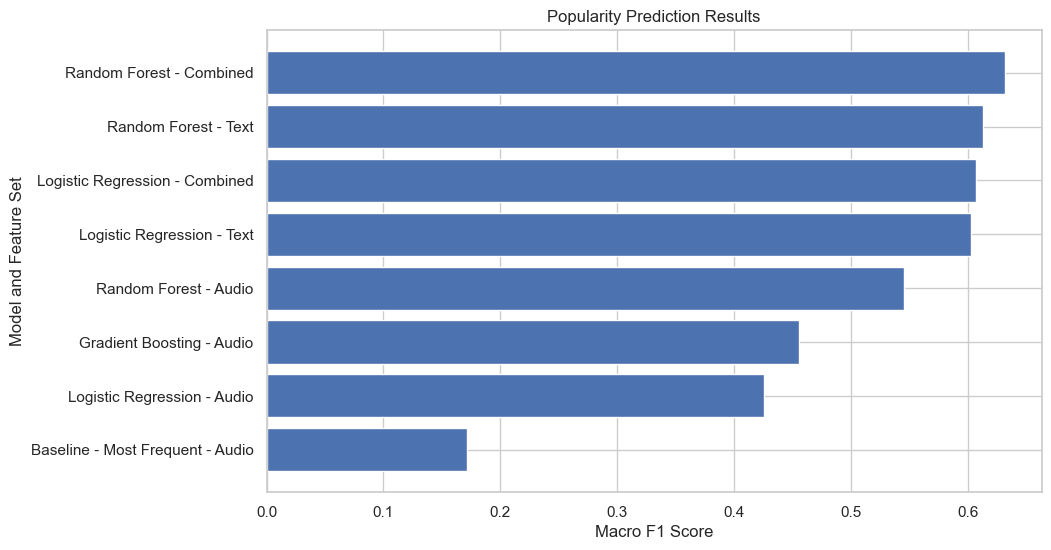

In [68]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Macro F1", ascending=False)

print(results_df)

plt.figure(figsize=(10, 6))
plt.barh(
    results_df["Model"] + " - " + results_df["Feature Set"],
    results_df["Macro F1"]
)

plt.xlabel("Macro F1 Score")
plt.ylabel("Model and Feature Set")
plt.title("Popularity Prediction Results")
plt.gca().invert_yaxis()
plt.show()

Several important patterns emerge from the final ranking.

1. The strongest models consistently involve textual information, either alone or combined with audio features. This suggests that popularity is more strongly associated with contextual and cultural metadata than with audio structure alone.
2. Random Forest achieves the best performance across nearly all feature spaces, reinforcing the idea that popularity depends on complex non-linear interactions between variables rather than simple linear relationships.
3. The improvement obtained by combining audio and text features remains relatively modest. Although audio contributes additional information, the majority of the predictive signal already appears to be encoded in the textual and contextual representations surrounding the music.
4. **Frankly speaking, even the best-performing models are not good.** No representation is capable of predicting popularity with extremely high accuracy, despite combining multiple feature types and non-linear models.

It reflects the reality of modern music consumption: commercial success is shaped not only by musical structure, but also by timing, recommendation systems, branding, cultural trends, audience behavior, and social exposure.In this sense, the results support one of the central conclusions of the entire study:
> musical structure is learnable, but musical success remains only partially predictable.

## B.11 FROM PREDICTION TO RECOMMENDATION

The previous models allow us to predict whether a song is likely to fall into a low, medium, or high popularity group. In this final step, we move from prediction to interpretation. Rather than asking only which model performs best, we ask which audio characteristics are associated with higher predicted popularity. To do this, we use the best-performing audio-based model and inspect its behavior with partial dependence plots. These plots show how the model’s predicted popularity changes as one feature changes, on average over the rest of the data. This helps us identify feature ranges that are associated with more favorable predictions.

[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(64,); total time=  28.7s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128,); total time= 1.3min
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(64,); total time=  27.0s
[CV] END activation=relu, alpha=0.001, hidden_layer_sizes=(128, 64); total time=  48.2s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(64,); total time=  24.6s
[CV] END activation=tanh, alpha=0.0001, hidden_layer_sizes=(128,); total time=  36.9s
[CV] END activation=tanh, alpha=0.001, hidden_layer_sizes=(64,); total time=  23.0s
[CV] END activation=tanh, alpha=0.001, hidden_layer_sizes=(64,); total time=  38.8s
[CV] END activation=tanh, alpha=0.001, hidden_layer_sizes=(128, 64); total time=  20.6s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128,); total time=  22.0s
[CV] END activation=relu, alpha=0.0001, hidden_layer_sizes=(128, 64); total time=  25.4s
[CV] END activation=relu, alpha=0.001, hidden_layer_siz

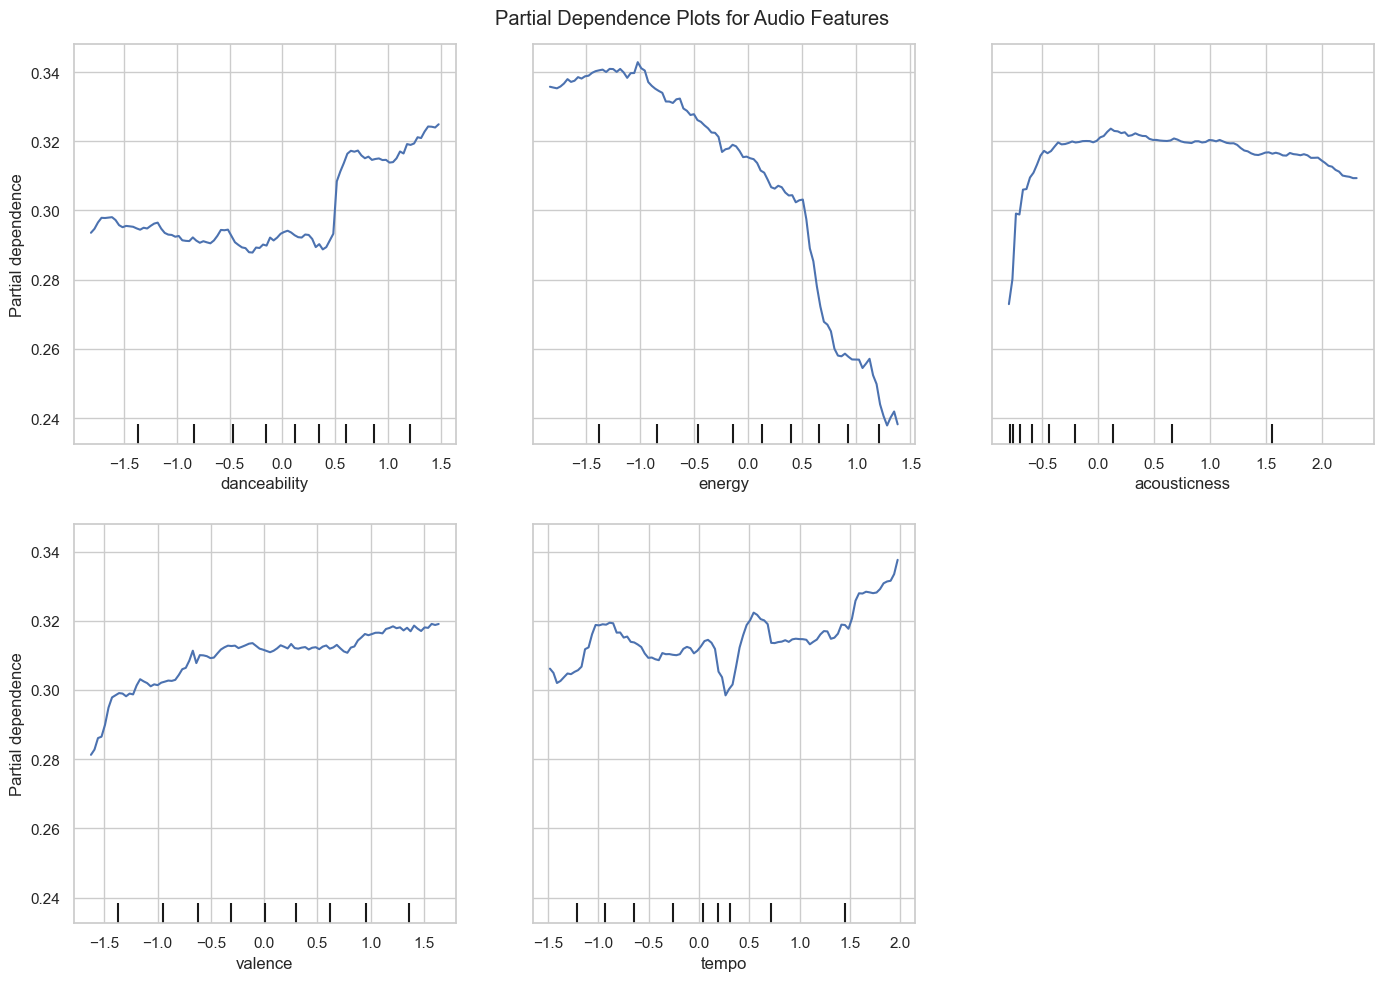

In [71]:
best_audio_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
best_audio_model.fit(X_audio_train_scaled, y_train)

features_to_explain = [
    audio_features.index("danceability"),
    audio_features.index("energy"),
    audio_features.index("acousticness"),
    audio_features.index("valence"),
    audio_features.index("tempo")
]

fig, ax = plt.subplots(figsize=(14, 10))
PartialDependenceDisplay.from_estimator(
    best_audio_model,
    X_audio_train_scaled,
    features_to_explain,
    feature_names=audio_features,
    target="high",
    response_method="predict_proba",
    kind="average",
    ax=ax
)
plt.suptitle("Partial Dependence Plots for Audio Features")
plt.tight_layout()
plt.show()

The partial dependence analysis suggests that popularity is not driven by extreme values of individual features, but rather by balanced combinations of musical characteristics. Several trends emerge from the plots:

- **Danceability** shows a generally positive relationship with predicted popularity, suggesting that more rhythmically accessible tracks are slightly more likely to achieve commercial success.
- **Valence** also exhibits a mild positive association, indicating that more upbeat or emotionally positive songs tend to receive more favorable predictions.
- **Acousticness** initially increases predicted popularity before stabilizing, implying that some degree of acoustic character may contribute positively, although the effect is limited.
- In contrast, very high levels of **energy** appear to reduce predicted popularity in the model, suggesting that extremely intense or aggressive tracks may appeal to narrower audiences.
- **Tempo** shows only moderate variation, indicating that no single BPM range strongly dominates commercial success.

Overall, the effects remain relatively smooth and moderate rather than extreme, there is not a single defining characteristic.

## B.12 SHAP

While Partial Dependence Plots describe average feature behavior, SHAP values provide a more detailed explanation of how individual features contribute to specific model predictions. SHAP (SHapley Additive exPlanations) decomposes the prediction of the Random Forest model into additive feature contributions, allowing us to estimate both:
- the overall importance of each audio feature
- the direction of its influence on predicted popularity
This makes the analysis more interpretable and helps identify which musical characteristics contribute most strongly to the model’s decision-making process.

In [ ]:
# Create SHAP explainer
explainer = shap.TreeExplainer(best_audio_model)

# Use a subset for speed
sample = X_audio_train_scaled[:1000]

# Compute SHAP values
shap_vals = explainer.shap_values(sample)

print("Type shap_vals:", type(shap_vals))

# Check model classes
print("Model classes:", best_audio_model.classes_)

# Pick class: "high"
class_idx = list(best_audio_model.classes_).index("high")

# Handle different SHAP output formats
if isinstance(shap_vals, list):
    # Old SHAP format: list[class] -> (samples, features)
    shap_high = shap_vals[class_idx]
else:
    # New SHAP format: (samples, features, classes)
    shap_high = shap_vals[:, :, class_idx]

print("shap_high shape:", shap_high.shape)
print("sample shape:", sample.shape)
print("Number of feature names:", len(audio_features))

# Build dataframe for feature importance
mean_abs_shap = np.abs(shap_high).mean(axis=0)
mean_shap = shap_high.mean(axis=0)

shap_df = pd.DataFrame({
    "feature": audio_features,
    "importance": mean_abs_shap,
    "avg_effect": mean_shap
}).sort_values("importance", ascending=False)

display(shap_df.head(10))

# IMPORTANT: create figure BEFORE summary_plot
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_high,
    sample,
    feature_names=audio_features,
    show=False
)

plt.title("SHAP Summary Plot - Class: High")
plt.tight_layout()
plt.show()

The SHAP analysis confirms that no single audio feature dominates popularity prediction. Instead, the Random Forest model relies on a distributed combination of multiple musical characteristics.Among the most influential variables are:
- **instrumentalness**
- **loudness**
- **duration**
- **energy**
- **danceability**

Interestingly, some of these effects are relatively subtle and context-dependent. For example, higher loudness and danceability often contribute positively to predictions, while very high energy levels sometimes reduce the probability of belonging to the high-popularity class. The SHAP summary plot also highlights substantial overlap between feature contributions. Songs with similar values can still receive different predictions depending on how the remaining characteristics interact together inside the model. This is an important result because it suggests that musical success does not emerge from a single “formula.” Even when measurable structure exists, popularity remains the outcome of many interacting acoustic, contextual, and cultural factors. In many ways, this mirrors the evolution of the music industry itself. There is no single feature that guarantees a modern *Thriller*. Streaming platforms may reward certain patterns, but commercial success still resists complete algorithmic explanation.

## B.13 RESULTS DISCUSSION

If Block A demonstrated that musical identity can be recovered remarkably well from language, Block B reveals a far more uncertain reality: commercial success is substantially harder to predict. Across all experiments, the models consistently extracted meaningful signals from both audio and textual representations. However, even the strongest configurations only achieved moderate predictive performance. This contrast becomes one of the most important findings of the entire project.

### Main Observations

- **Textual representations consistently outperformed audio-only features**, suggesting that popularity is influenced as much by cultural and contextual framing as by the intrinsic sound of the music itself.
- **Random Forest achieved the strongest overall performance across most feature spaces**, indicating that popularity depends on non-linear interactions between multiple variables rather than simple linear relationships.
- **Combining audio and text features produced the best results overall**, but the improvement over text alone remained relatively modest. This suggests that contextual metadata already captures much of the available predictive signal.
- **Audio-only models still performed substantially above the baseline**, confirming that musical structure does contribute to popularity, even if it does not fully determine it.
- **No model achieved extremely high performance**, despite combining multiple representations and non-linear architectures. This limitation is itself one of the project’s most meaningful conclusions.

### What the Models Actually Learned

The models appear to learn patterns associated with accessibility, visibility, and recommendation environments rather than discovering a universal formula for musical success. Audio features such as danceability, loudness, valence, and energy contributed measurable signals, while textual metadata captured contextual information surrounding artists, playlists, and listener culture. Together, these variables created partially predictable structures inside the popularity labels. However, a large portion of popularity remained unexplained. In other words, the models can partially identify the conditions under which songs become successful, but they cannot fully explain why one song becomes globally dominant while another remains unnoticed.

### Interpreting the Role of Text

One of the most interesting results of the block is that textual information proved more predictive than audio structure itself, which reflects the reality of the streaming era.
Modern music consumption is deeply mediated by metadata ecosystems:
- Playlist names
- Artist recognition
- Recommendation categories
- Mood labels
- Social identity
- Algorithmic curation

The models therefore learn not only music, but the environment surrounding music.

### Why *Thriller* Matters Here

*Thriller* serves as the symbolic center of this block because it represents a moment when commercial success still felt tied to cultural scale and artistic impact. Michael Jackson did not become globally dominant because an algorithm optimized his retention curve after thirty seconds. *Thriller* succeeded through performance, production, timing, innovation, and mass cultural presence, but today, success often behaves differently. Streaming platforms reward replayability, immediacy, and discoverability. Songs compete inside algorithmic systems where visibility can matter as much as composition itself, which does not necessarily mean that artistic quality disappeared, but it does mean that success is no longer reducible to music alone.

### Broader Implications

The results of Block B ultimately suggest that popularity behaves fundamentally differently from genre or musical identity. Genre reflects relatively stable structural patterns that machine learning models can recover quite effectively, while popularity emerges from a hybrid interaction between:
- Musical structure
- Cultural context
- Platform dynamics
- Collective human behavior

**Again, this makes  success only partially predictable, and this limitation is reassuring, funnily enough. If popularity could be perfectly predicted from measurable variables alone, music would begin to resemble a solved optimization problem rather than a cultural and emotional medium shaped by unpredictability, identity, and collective experience. Instead, the models reveal something more human: there are patterns in success, but there is still no guaranteed formula for creating the next *Thriller*.**

## **C: MUSIC BEYOND GENRE LABELS WITH EL MADRILEÑO BY C. TANGANA** → CLUSTERING

Some albums challenge the idea that music must belong to a single category. *El Madrileño* by C. Tangana is built precisely around this tension: flamenco, latin pop, rap, folk, and traditional Spanish influences coexist within the same project without fitting neatly into one genre label. This block is inspired by that fluidity.

Rather than predicting predefined categories, we remove labels entirely and allow the songs to organize themselves through unsupervised learning. The objective is to investigate whether Spotify audio features naturally form distinct musical groups, or whether modern music behaves more like a continuous overlapping space where rigid genre boundaries become increasingly difficult to define.

## C.1 FEATURE SELECTION AND DEDUPLICATION

For the clustering stage, only the numerical audio features extracted from the Spotify API are used. These variables describe measurable aspects of the music itself, including rhythm, intensity, emotional tone, acoustic texture, and energy.

The final feature set contains **12 audio variables**:

- danceability
- energy
- key
- loudness
- mode
- speechiness
- acousticness
- instrumentalness
- liveness
- valence
- tempo
- duration_ms

Variables such as track titles, playlist names, or artist metadata are intentionally excluded from this stage. Those fields describe commercial framing and semantic identity rather than the sound itself. Including them would risk pushing the clustering process toward external cultural labels instead of acoustic structure.

Before clustering, duplicate observations are removed from the dataset. The original dataset contained 32,828 songs, but after deduplication the dataset was reduced to 27,628 observations, meaning that 5,200 duplicated tracks were removed.

This step is methodologically important because clustering algorithms rely entirely on geometric proximity inside the feature space. Repeated tracks artificially amplify certain acoustic profiles, creating structural bias by making some regions appear denser than they actually are.

## C.1 FEATURE SELECTION FOR CLUSTERING

In [ ]:
audio_features_cluster = [
    "danceability", "energy", "key", "loudness", "mode",
    "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "duration_ms"
]

df_cluster = df_clean.drop_duplicates(subset=audio_features_cluster).reset_index(drop=True)

print(f"Original dataset         : {len(df_clean):,} rows")
print(f"After deduplication      : {len(df_cluster):,} rows")
print(f"Duplicate tracks removed : {len(df_clean) - len(df_cluster):,}")

df_cluster = df_cluster[audio_features_cluster].copy()

print(f"\nSelected features ({len(audio_features_cluster)}):")
for feat in audio_features_cluster:
    print(f"  · {feat}")

## C.2 SCALING

All features are standardised with ⁠ StandardScaler ⁠ (zero mean, unit variance) before any further step. Scaling is essential for two reasons:

1.⁠ ⁠*Distance-based clustering (K-Means)* computes Euclidean distances. Features measured on larger scales: tempo ⁠ (40–220 BPM) or ⁠ duration_ms ⁠ (tens of thousands). These would dominate the distance metric and effectively suppress features measured on the [0, 1] range (e.g., ⁠ danceability ⁠), leading to clusters driven entirely by a few high-variance features.

2.⁠ ⁠*PCA* is a variance-maximisation procedure. Without scaling, components would be aligned with the features of greatest absolute variance rather than those carrying the most musical information.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler_cluster = StandardScaler()
X_scaled = scaler_cluster.fit_transform(df_cluster[audio_features_cluster])


print(f"Scaled matrix shape : {X_scaled.shape}")
print(f"Per-feature mean (expect ≈ 0) : {X_scaled.mean(axis=0).round(4)}")
print(f"Per-feature std  (expect ≈ 1) : {X_scaled.std(axis=0).round(4)}")

## C.3 PRINCIPAL COMPONENT ANALYSIS (PCA)

Before clustering, Principal Component Analysis (PCA) is applied to reduce the dimensionality of the dataset.

PCA identifies the directions of maximum variance inside the feature space and compresses the information into a smaller set of synthetic dimensions. This process reduces redundancy and noise while preserving the strongest structural patterns present in the data.

In [ ]:
# Full PCA to inspect explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained    = pca_full.explained_variance_ratio_
cumulative   = np.cumsum(explained)
n_components = len(explained)

# ── Plot: variance per component + cumulative ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, n_components + 1), explained * 100,
            color="steelblue", alpha=0.85, edgecolor="white")
axes[0].set_xlabel("Principal Component", fontsize=12)
axes[0].set_ylabel("Explained Variance (%)", fontsize=12)
axes[0].set_title("Variance Explained per Component", fontsize=13)
axes[0].set_xticks(range(1, n_components + 1))

axes[1].plot(range(1, n_components + 1), cumulative * 100,
             marker="o", color="steelblue", linewidth=2)
axes[1].axhline(y=80, color="tomato", linestyle="--", linewidth=1.5, label="80 % threshold")
axes[1].axhline(y=90, color="orange", linestyle="--", linewidth=1.5, label="90 % threshold")
axes[1].set_xlabel("Number of Components", fontsize=12)
axes[1].set_ylabel("Cumulative Explained Variance (%)", fontsize=12)
axes[1].set_title("Cumulative Explained Variance", fontsize=13)
axes[1].legend(fontsize=10)
axes[1].set_xticks(range(1, n_components + 1))

plt.suptitle("PCA — Explained Variance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print summary table
print(f"{'PC':>4} | {'Variance (%)':>12} | {'Cumulative (%)':>14}")
print("-" * 36)
for i, (v, c) in enumerate(zip(explained, cumulative), start=1):
    marker = " ◄ 80%" if abs(c - 0.80) == min(abs(cumulative - 0.80)) else ""
    print(f"PC{i:>2} | {v*100:>11.2f}% | {c*100:>13.2f}%{marker}")

# ── Choose components: 80 % threshold ────────────────────────────────────────
n_pca_cluster = int(np.argmax(cumulative >= 0.80)) + 1
print(f"\\nComponents needed to reach ≥ 80 % cumulative variance: {n_pca_cluster}")

pca_cluster = PCA(n_components=n_pca_cluster, random_state=42)
X_pca = pca_cluster.fit_transform(X_scaled)
print(f"PCA-reduced matrix shape (for clustering) : {X_pca.shape}")

# ── Fixed 2-D projection for all visualisations ───────────────────────────────
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)
pc1_var = pca_2d.explained_variance_ratio_[0] * 100
pc2_var = pca_2d.explained_variance_ratio_[1] * 100
print(f"\\n2-D projection: PC1 = {pc1_var:.1f} %, PC2 = {pc2_var:.1f} %")

# ── 2-D PCA scatter: density view and genre-coloured view ─────────────────────
genres_array = df_clean.drop_duplicates(subset=audio_features_cluster)["playlist_genre"].values
unique_genres = sorted(set(genres_array))
palette_genre = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Left – plain scatter (all songs)
axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                alpha=0.04, s=5, color="steelblue")
axes[0].set_xlabel(f"PC1 ({pc1_var:.1f} % var.)", fontsize=11)
axes[0].set_ylabel(f"PC2 ({pc2_var:.1f} % var.)", fontsize=11)
axes[0].set_title("PCA Projection — All Songs", fontsize=13)

# Right – coloured by playlist genre
for i, g in enumerate(unique_genres):
    mask = genres_array == g
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    alpha=0.12, s=5, color=palette_genre[i], label=g)
axes[1].set_xlabel(f"PC1 ({pc1_var:.1f} % var.)", fontsize=11)
axes[1].set_ylabel(f"PC2 ({pc2_var:.1f} % var.)", fontsize=11)
axes[1].set_title("PCA Projection — Coloured by Genre", fontsize=13)
axes[1].legend(markerscale=6, title="Genre", fontsize=9,
               bbox_to_anchor=(1.02, 1), loc="upper left")

plt.suptitle("2-D PCA Projection of Audio Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

*Interpretation.* 

Looking at the explained variance results, the first principal component explains **18.09%** of the total variance, while the second explains **12.94%**. Together, the first two components account for approximately **31.03%** of the total variance.

The cumulative explained variance curve shows a gradual decline rather than a sharp concentration around a single dominant axis. To preserve at least 80% of the total variance, the model requires **8 principal components**, which together explain approximately **81.85%** of the information contained in the original feature space.

This result is important because it suggests that musical structure in the dataset is not governed by one singular emotional direction or stylistic contrast. Instead, it is distributed across multiple overlapping dimensions.

The PCA visualizations reinforce this interpretation. In the two-dimensional projection, observations form a dense and highly overlapping cloud rather than sharply separated regions. When the projection is colored by genre, the overlap becomes even more visible. Genres such as EDM, pop, rap, R&B, rock, and latin music occupy many of the same regions in the PCA space.

This suggests that acoustic similarity frequently transcends commercial genre labels. Songs categorized differently may still share rhythmic behavior, production aesthetics, or emotional texture.

## C.4 K-MEANS

K-Means is used to identify latent acoustic groupings within the PCA-reduced feature space.

The algorithm alternates between assigning observations to the nearest centroid and updating centroid positions based on the average location of the assigned points. Through this iterative process, the feature space gradually organizes itself into regions defined by acoustic similarity.

To determine the optimal number of clusters, the Elbow Method and silhouette analysis are evaluated across values of **k = 2 to 11**.

In [ ]:
# ── K selection: Elbow method and Silhouette score ────────────────────────────
k_range = range(2, 12)
inertias = []
silhouette_scores_k = []

print(f"{'k':>3} | {'Inertia':>14} | {'Silhouette':>10}")
print("-" * 36)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_pca)

    inertias.append(km.inertia_)

    sil = silhouette_score(
        X_pca,
        labels_k,
        sample_size=5000,
        random_state=42
    )
    silhouette_scores_k.append(sil)

    print(f"{k:>3} | {km.inertia_:>14.1f} | {sil:>10.4f}")

# ── Plots: Elbow and Silhouette ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(
    list(k_range),
    inertias,
    marker="o",
    color="steelblue",
    linewidth=2
)
axes[0].set_xlabel("Number of Clusters (k)", fontsize=12)
axes[0].set_ylabel("Inertia (Within-Cluster SS)", fontsize=12)
axes[0].set_title("Elbow Method", fontsize=13)
axes[0].set_xticks(list(k_range))

axes[1].plot(
    list(k_range),
    silhouette_scores_k,
    marker="o",
    color="tomato",
    linewidth=2
)
axes[1].set_xlabel("Number of Clusters (k)", fontsize=12)
axes[1].set_ylabel("Silhouette Score", fontsize=12)
axes[1].set_title("Silhouette Score by k", fontsize=13)
axes[1].set_xticks(list(k_range))

plt.suptitle("K-Means: Cluster Number Selection", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Final K-Means with chosen k ───────────────────────────────────────────────
FINAL_K = 6

km_final = KMeans(n_clusters=FINAL_K, random_state=42, n_init=20)
cluster_labels = km_final.fit_predict(X_pca)

# ────────────────────────────────────
cluster_names = {
    0: "Danceable Speech-Heavy Tracks",
    1: "Happy Dance-Pop Tracks",
    2: "Acoustic Mellow Tracks",
    3: "Live High-Energy Tracks",
    4: "Instrumental Electronic Tracks",
    5: "Intense Fast-Paced Tracks"
}

# ── Attach labels and external metadata for later analysis ────────────────────
df_cluster = df_cluster.copy()

df_cluster["cluster"] = cluster_labels
df_cluster["cluster_name"] = df_cluster["cluster"].map(cluster_names)
df_cluster["playlist_genre"] = df_clean.drop_duplicates(subset=audio_features_cluster)["playlist_genre"].values
df_cluster["track_popularity"] = df_clean.drop_duplicates(subset=audio_features_cluster)["track_popularity"].values


# ── Print cluster size distribution ───────────────────────────────────────────
print(f"Final model: K-Means, k = {FINAL_K}")
print("\nCluster size distribution:")

for c in range(FINAL_K):
    n = int((cluster_labels == c).sum())
    cluster_label = cluster_names[c]
    percentage = n / len(cluster_labels) * 100

    print(f"  {cluster_label}: {n:>6} songs  ({percentage:.1f} %)")

# ── Visualisation: clusters in 2-D PCA space ──────────────────────────────────
palette_cluster = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(10, 7))

for c in range(FINAL_K):
    mask = cluster_labels == c

    ax.scatter(
        X_pca_2d[mask, 0],
        X_pca_2d[mask, 1],
        alpha=0.18,
        s=7,
        color=palette_cluster[c],
        label=cluster_names[c]
    )

ax.set_xlabel(f"PC1 ({pc1_var:.1f} % var.)", fontsize=12)
ax.set_ylabel(f"PC2 ({pc2_var:.1f} % var.)", fontsize=12)
ax.set_title(f"K-Means Clusters (k = {FINAL_K}) in PCA Space", fontsize=14)

ax.legend(
    markerscale=5,
    title="Cluster Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

*Interpretation.*

The inertia curve decreases steadily as k increases, while silhouette scores remain relatively low across all configurations. The highest silhouette score appears at **k = 2** with a value of **0.1729**, although this solution produces clusters that are overly broad and insufficiently informative for musical interpretation.

The final model therefore uses **k = 6**. The resulting silhouette score for this configuration is **0.1357**.

The PCA cluster visualization shows partial separation between groups, but also significant overlap between several clusters.

## C.5 EVALUATION

The silhouette score is used as the primary metric for evaluating clustering quality:

$$s(i) = \\frac{b(i) - a(i)}{\\max(a(i),\\, b(i))}$$

where $a(i)$ is the mean intra-cluster distance and $b(i)$ is the mean distance to the nearest other cluster. The global score is the average across all points.

| Score range | Interpretation |
|-------------|----------------|
| ≥ 0.50 | Well-separated clusters |
| 0.25 – 0.50 | Moderate structure |
| < 0.25 | Weak or overlapping clusters |

In high-dimensional, real-world datasets with soft category boundaries (such as music), moderate scores are expected and do not imply that the clustering is uninformative.

We additionally report the *Davies-Bouldin index* (lower is better) and the *Calinski-Harabász index* (higher is better) as supplementary metrics.

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sil_final = silhouette_score(X_pca, cluster_labels, sample_size=10000, random_state=42)
db_final  = davies_bouldin_score(X_pca, cluster_labels)
ch_final  = calinski_harabasz_score(X_pca, cluster_labels)

print("=" * 50)
print(f"  Silhouette Score        : {sil_final:.4f}")
print(f"  Davies-Bouldin Index    : {db_final:.4f}  (↓ better)")
print(f"  Calinski-Harabász Index : {ch_final:.1f}  (↑ better)")
print("=" * 50)

quality = "strong" if sil_final >= 0.50 else ("moderate" if sil_final >= 0.25 else "weak")
print(f"\\nOverall clustering quality: {quality.upper()}  (silhouette = {sil_final:.4f})")

The final K-Means configuration achieves a silhouette score of **0.1357**, indicating relatively weak global separation between clusters.

Additional evaluation metrics reinforce this conclusion:

- **Davies–Bouldin Index: 1.7793**
- **Calinski–Harabasz Index: 3380.0**

The Davies–Bouldin score suggests moderate overlap between clusters, while the Calinski–Harabasz value indicates that some meaningful structural separation still exists inside the feature space.

Taken together, these results imply that the dataset contains latent structure, but that this structure remains fluid and continuous rather than sharply partitioned.

This does not necessarily represent a methodological failure. On the contrary, it reflects something important about contemporary music itself. Genres increasingly dissolve into one another, and rigid labels often fail to capture the true emotional or acoustic identity of a song.

The clustering quality is therefore classified as **weak**, but the weakness itself becomes informative. The model reveals that musical identity behaves more like a spectrum than a set of isolated categories.

## C.6 ALTERNATIVE MODELS

To evaluate the robustness of the latent structure, two additional clustering algorithms are tested on the same PCA-reduced space: Gaussian Mixture Models (GMM) and DBSCAN.
⁠
- ⁠**Gaussian Mixture Model (GMM):** GMM extends the logic of K-Means by modeling clusters probabilistically rather than assigning observations deterministically.

- **DBSCAN (Density-Based Spatial Clustering of Applications with Noise):** DBSCAN approaches clustering through density estimation rather than centroid optimization.

In [ ]:
# ── GMM ───────────────────────────────────────────────────────────────────────
gmm = GaussianMixture(n_components=FINAL_K, covariance_type="full",
                      random_state=42, n_init=5)
gmm_labels = gmm.fit_predict(X_pca)
sil_gmm = silhouette_score(X_pca, gmm_labels, sample_size=10000, random_state=42)
print(f"GMM  (k={FINAL_K}) — Silhouette : {sil_gmm:.4f}")

# ── DBSCAN — eps estimated from k-NN distance distribution ───────────────────
nbrs = NearestNeighbors(n_neighbors=5, n_jobs=-1).fit(X_pca)
nn_distances, _ = nbrs.kneighbors(X_pca)

# Plot the k-NN distance curve to find the elbow visually
distances_sorted = np.sort(nn_distances[:, -1])
plt.figure(figsize=(8, 4))
plt.plot(distances_sorted, color="steelblue", linewidth=1.5)
plt.xlabel("Points sorted by 5-NN distance", fontsize=11)
plt.ylabel("5-NN distance", fontsize=11)
plt.title("k-NN Distance Plot — elbow guides eps choice", fontsize=12)
plt.tight_layout()
plt.show()

# Empirical eps based on elbow (~22nd percentile for this dataset)
eps_estimate = float(np.percentile(nn_distances[:, -1], 22))
print(f"DBSCAN estimated eps (22nd-pct 5-NN dist.): {eps_estimate:.3f}")

dbs = DBSCAN(eps=eps_estimate, min_samples=20, n_jobs=-1)
dbs_labels = dbs.fit_predict(X_pca)
n_clusters_dbs = len(set(dbs_labels)) - (1 if -1 in dbs_labels else 0)
n_noise        = int((dbs_labels == -1).sum())
print(f"DBSCAN — Clusters found : {n_clusters_dbs}  |  Noise points : {n_noise} "
      f"({n_noise / len(dbs_labels) * 100:.1f} %)")

if n_clusters_dbs > 1:
    valid_mask = dbs_labels != -1
    sil_dbs = silhouette_score(X_pca[valid_mask], dbs_labels[valid_mask],
                               sample_size=10000, random_state=42)
    print(f"DBSCAN — Silhouette (non-noise) : {sil_dbs:.4f}")
else:
    sil_dbs = None
    print("DBSCAN — Insufficient clusters for silhouette score.")

# ── Comparison table ──────────────────────────────────────────────────────────
print("\\n" + "─" * 55)
print(f"{'Model':<20} {'Silhouette':>10}  {'Notes'}")
print("─" * 55)
print(f"{'K-Means':<20} {sil_final:>10.4f}  k={FINAL_K}, hard assignment")
print(f"{'GMM':<20} {sil_gmm:>10.4f}  k={FINAL_K}, soft / elliptical")
if sil_dbs is not None:
    print(f"{'DBSCAN':<20} {sil_dbs:>10.4f}  k={n_clusters_dbs}, density-based")
else:
    print(f"{'DBSCAN':<20} {'N/A':>10}  insufficient clusters")
print("─" * 55)

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

for c in range(FINAL_K):
    mask = gmm_labels == c
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    alpha=0.14, s=6, color=palette_cluster[c], label=f"Cluster {c}")
axes[0].set_title(f"GMM Clusters (k = {FINAL_K})", fontsize=13)
axes[0].set_xlabel("PC1", fontsize=11); axes[0].set_ylabel("PC2", fontsize=11)
axes[0].legend(markerscale=5, bbox_to_anchor=(1.01, 1), loc="upper left")

unique_dbs_ids = sorted(set(dbs_labels))
color_map_dbs  = {-1: "lightgray"}
for i, c in enumerate(x for x in unique_dbs_ids if x != -1):
    color_map_dbs[c] = palette_cluster[i % len(palette_cluster)]

for c in unique_dbs_ids:
    mask  = dbs_labels == c
    label = "Noise" if c == -1 else f"Cluster {c}"
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    alpha=0.08, s=5, color=color_map_dbs[c], label=label)
axes[1].set_title("DBSCAN Clusters", fontsize=13)
axes[1].set_xlabel("PC1", fontsize=11); axes[1].set_ylabel("PC2", fontsize=11)
axes[1].legend(markerscale=5, bbox_to_anchor=(1.01, 1), loc="upper left")

plt.suptitle("Alternative Clustering Models — 2-D PCA View",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

*Interpretation.*

- **Gaussian Mixture Model (GMM)**

The final GMM configuration with **k = 6** achieves a silhouette score of only **0.0317**, substantially lower than K-Means.

The PCA visualization shows highly overlapping elliptical structures with very limited separation between groups. Although GMM introduces greater flexibility, the model ultimately struggles to identify meaningful acoustic boundaries inside the dataset.

- **DBSCAN**

DBSCAN approaches clustering through density estimation rather than centroid optimization.

Using the estimated epsilon value of **0.722**, DBSCAN identifies **4 clusters**, but classifies **25,252** observations as noise points, corresponding to approximately **91.4%** of the dataset.

The resulting silhouette score is **−0.1581**, indicating extremely poor clustering quality.

The PCA visualization confirms this behavior. Most observations collapse into a diffuse background cloud while only a small dense region remains classified as a cluster.


*Comparison.*

Among the three methods, K-Means performs best despite its relatively weak silhouette score.

- **K-Means: 0.1357**
- **GMM: 0.0317**
- **DBSCAN: −0.1581**

K-Means therefore remains the most interpretable and stable solution for this dataset.

The broader implication is that the musical landscape represented in the data behaves less like isolated acoustic islands and more like a continuous urban environment where influences constantly overlap.

## C.7 CLUSTER INTERPRETATION

Once the clustering structure is established, each cluster is analyzed through its normalized audio-feature profiles, genre composition, and popularity distributions.

The objective is not only to verify whether clusters exist mathematically, but also whether they correspond to musically interpretable identities.

The heatmaps and cluster summaries reveal several coherent acoustic patterns.

In [ ]:
# ── Rename clusters with descriptive labels ──────────────────────────────────
cluster_names = {
    0: "Danceable Speech-Heavy Tracks",
    1: "Happy Dance-Pop Tracks",
    2: "Acoustic Mellow Tracks",
    3: "Live High-Energy Tracks",
    4: "Instrumental Electronic Tracks",
    5: "Intense Fast-Paced Tracks"
}

df_cluster["cluster_name"] = df_cluster["cluster"].map(cluster_names)

cluster_order = [cluster_names[i] for i in range(6)]

# ── Mean audio features per cluster ──────────────────────────────────────────
cluster_means = (
    df_cluster
    .groupby("cluster_name")[audio_features_cluster]
    .mean()
    .loc[cluster_order]
)

# Normalise to [0, 1] for readability in the heatmap
mm_scaler = MinMaxScaler()

cluster_means_norm = pd.DataFrame(
    mm_scaler.fit_transform(cluster_means),
    index=cluster_means.index,
    columns=cluster_means.columns
)

fig, ax = plt.subplots(figsize=(15, 6))

sns.heatmap(
    cluster_means_norm,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.4,
    ax=ax,
    cbar_kws={"label": "Normalised Mean Value"}
)

ax.set_title(
    "Normalised Mean Audio Features per Cluster",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Audio Feature", fontsize=11)
ax.set_ylabel("Cluster Type", fontsize=11)

plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nRaw cluster means (rounded to 3 d.p.):")
display(cluster_means.round(3))

# ── Genre distribution per cluster ───────────────────────────────────────────
genre_crosstab = pd.crosstab(
    df_cluster["cluster_name"],
    df_cluster["playlist_genre"],
    normalize="index"
) * 100

# Keep same cluster order
genre_crosstab = genre_crosstab.loc[cluster_order]

fig, ax = plt.subplots(figsize=(12, 5))

genre_crosstab.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    colormap="tab10",
    edgecolor="none"
)

ax.set_title(
    "Genre Composition Within Each Cluster (%)",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Cluster Type", fontsize=11)
ax.set_ylabel("Proportion (%)", fontsize=11)
ax.legend(
    title="Genre",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=9
)

plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

print("\nGenre distribution per cluster (row %):")
display(genre_crosstab.round(1))

# ── Track popularity per cluster ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

df_cluster.boxplot(
    column="track_popularity",
    by="cluster_name",
    ax=ax,
    notch=False,
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.5),
    medianprops=dict(color="tomato", linewidth=2)
)

ax.set_title(
    "Track Popularity Distribution by Cluster",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Cluster Type", fontsize=11)
ax.set_ylabel("Track Popularity (0–100)", fontsize=11)

plt.xticks(rotation=25, ha="right")
plt.suptitle("")
plt.tight_layout()
plt.show()

print("\nMean track popularity per cluster:")
print(
    df_cluster
    .groupby("cluster_name")["track_popularity"]
    .mean()
    .loc[cluster_order]
    .round(2)
)

print("\nMedian track popularity per cluster:")
print(
    df_cluster
    .groupby("cluster_name")["track_popularity"]
    .median()
    .loc[cluster_order]
    .round(2)
)

df_cluster["cluster"] = cluster_labels

### **Danceable Speech-Heavy Tracks**

This cluster shows high values for **danceability (0.669)**, **energy (0.777)**, and especially **instrumentalness (0.747)**. It is heavily dominated by EDM, which represents approximately **56.6%** of the cluster composition.

The atmosphere here feels mechanical, repetitive, and highly rhythmic, closer to underground electronic spaces than emotional songwriting.

Despite its energetic profile, this cluster shows the lowest popularity values, with a mean popularity of only **29.50** and median of **32.0**.

### **Happy Dance-Pop Tracks**

This cluster combines high **energy (0.792)** with elevated **tempo (133.645)** and balanced danceability.

The genre distribution is highly mixed, with strong representations from pop, rock, and EDM. The cluster feels commercially accessible and structurally familiar, resembling polished radio-oriented production.

Popularity levels are noticeably higher, with a mean popularity of **38.87** and median of **42.0**.

### **Acoustic Mellow Tracks**

This cluster displays higher **acousticness (0.117)** and elevated **liveness (0.598)**, suggesting softer and more intimate production styles.

The genre distribution is relatively balanced across multiple genres, reinforcing the idea that emotional atmosphere often transcends commercial categorization.

The cluster carries a quieter and more reflective identity.

### **Live High-Energy Tracks**

This cluster is strongly defined by extremely high **speechiness (0.300)** and elevated **danceability (0.736)**.

Rap dominates the cluster composition with approximately **56.7%** of observations, making it one of the most concentrated groups in the dataset.

The atmosphere feels direct, loud, and confrontational, associated with contemporary urban music culture.

The cluster also achieves relatively strong popularity values, with a mean popularity of **41.13** and median of **44.0**.

### **Instrumental Electronic Tracks**

This cluster shows the highest **acousticness (0.515)** and very low **energy (0.418)** and **loudness (-10.748)** values.

The resulting atmosphere feels colder, slower, and more introspective. The genre composition remains highly mixed, although R&B and rap hold significant representation.

Interestingly, this cluster achieves the highest median popularity value at **45.0**, suggesting that softer and more atmospheric production styles still maintain substantial audience appeal.

### **Intense Fast-Paced Tracks**

This is the largest cluster in the dataset, representing **31.4%** of all observations.

It combines extremely high **danceability (0.738)**, elevated **valence (0.687)**, and strong overall energy.

The cluster feels fast, dense, and emotionally immediate, capturing the intensity of modern commercial production designed for movement and instant engagement.

Popularity values remain consistently high, with a mean popularity of **40.97** and median of **44.0**.

## C.8 GENRE AND POPULARITY ANALYSIS


One of the most important findings emerges from the relationship between clusters, genres, and popularity. Although certain clusters show partial genre dominance, most groups remain highly mixed. Pop, rap, EDM, latin, rock, and R&B repeatedly overlap across multiple acoustic regions; which suggests that traditional genre labels only partially describe the deeper structure of contemporary music.

Songs categorized differently may still share production aesthetics, rhythmic behavior, emotional tone, or acoustic texture. The popularity distributions reinforce this complexity. More energetic and rhythmically intense clusters tend to achieve higher median popularity values, but the differences remain relatively moderate across groups.

 Popularity cannot be explained entirely through isolated musical attributes or rigid stylistic categories. Instead, it emerges from a complex interaction between sound, culture, production aesthetics, and emotional atmosphere; going back once again to the same point.

## C.9 CONCLUSION

The clustering analysis demonstrates that Spotify audio features contain meaningful latent musical structure even in the absence of explicit labels.

Using PCA and K-Means, the dataset organizes itself into acoustically interpretable regions shaped by variables such as **energy, danceability, speechiness, and acousticness**. These structures emerge naturally from the data rather than being imposed externally. At the same time, the relatively low silhouette scores and the strong overlap visible in the PCA projections reveal that musical identities are not cleanly separated. Most songs occupy intermediate positions between styles, reflecting the hybrid and fluid nature of contemporary music.

Genre labels therefore capture only part of the story. The results also suggest that popularity cannot be explained through a single acoustic formula. Although more energetic and rhythmically intense clusters tend to achieve slightly higher popularity values, the differences remain moderate across groups, reinforcing the idea that commercial success emerges from a combination of sound, cultural context, production aesthetics, and emotional atmosphere.

*Limitations and possible improvements.*

Some limitations should still be acknowledged. The clustering quality remains relatively weak, with significant overlap between observations, and the Spotify audio features cannot fully capture lyrical meaning, cultural nuance, or emotional narrative. Additionally, PCA inevitably compresses part of the original information contained in the dataset.

Future improvements could involve richer representations of music, lyrical analysis, or more advanced dimensionality reduction techniques like UMAP, which may reveal subtler latent structures. Even so, the ambiguity visible throughout the analysis becomes meaningful in itself. Like the Madrid portrayed in *El Madrileño*, the dataset resists rigid categorization. Its identity is built through contradiction, movement, reinvention, and the constant tension between roots and modern ambition.

# **3. Discussion**

The results showed clear differences between the information captured by text and audio features. Text-based models performed best for genre classification, with TF-IDF reaching up to 93% accuracy and Macro F1, which suggests that playlist titles and song names contain stronger genre indicators than Spotify audio features alone. In many ways, this reflects the central idea behind *21* by Adele: music is not experienced only through sound, but also through language, emotion, narrative, and identity. The models were often able to recognize genres simply from the way songs and playlists were described, showing that musical culture leaves strong linguistic traces inside streaming platforms.

Popularity prediction was much more limited across all models. Even the best-performing model only reached 63% accuracy/F1, suggesting that popularity depends on many factors outside the dataset itself, such as recommendation systems, artist visibility, marketing, trends, or audience behavior. This contrast became one of the most important conclusions of the project. While musical identity appears relatively structured and learnable, commercial success behaves much more unpredictably. In the era represented symbolically by *Thriller*, success still felt tied to artistic scale and cultural impact; today, popularity is increasingly filtered through algorithms, playlists, visibility systems, and audience attention economies.

The clustering results also showed weak separation between genres. Even after reducing dimensionality with PCA, methods such as K-Means and GMM produced very low silhouette scores, indicating that genres overlap heavily instead of forming clearly separated groups. This result aligns strongly with the philosophy behind albums such as *El Madrileño* by C. Tangana, where flamenco, latin pop, rap, folk, and traditional Spanish music coexist fluidly inside the same project. Modern music appears to behave less like isolated categories and more like a continuous space of overlapping influences and hybrid identities.

Overall, the three analytical blocks complement one another surprisingly well. **Textual information captures identity, audio features capture structure, and clustering reveals the limits of rigid categorization. Together, the results suggest that music can be partially mapped through machine learning, but never fully reduced to a single representation.**

# **4. Limitations**

There are several limitations that need to be considered regarding this project. Spotify audio features simplify music into predefined numerical metrics that may not fully represent musical structure or style. Important aspects such as lyrical meaning, cultural context, production complexity, emotional interpretation, or artistic intention cannot be completely reduced to numerical descriptors. Genre labels are also subjective and inconsistent, especially since many songs fit into multiple genres at the same time.

Some of the methods used also introduce limitations. Clustering algorithms such as K-Means assume relatively separable group structures; however, the results suggest that music genres overlap heavily in practice. Supervised models also depend entirely on the labels provided in the dataset, so inconsistencies in genre classification directly affect model performance. This becomes particularly relevant in contemporary music, where artists increasingly blend styles rather than remaining inside clearly defined categories.

Another limitation is that the dataset only includes Spotify metadata and audio features. External factors that likely influence popularity, such as streaming behavior, recommendation algorithms, social media activity, or marketing exposure, were not included in the analysis. As a result, the models can only capture the portion of popularity that is structurally encoded inside the dataset itself.

The project is also limited by the way streaming platforms represent music. Spotify features are designed for recommendation systems rather than for deep musicological analysis, meaning that some variables may reflect platform-specific interpretations of music rather than objective artistic structure. In this sense, the models are not only learning music; they are also learning the logic through which streaming platforms organize music.

# **5. Conclusion and Future Steps**

In conclusion, the project showed that machine learning models can identify meaningful patterns in music data, especially for genre classification tasks. However, the results also showed that music popularity and genre structure cannot be fully explained using Spotify features alone. Some aspects of music appear highly structured and predictable, while others remain shaped by cultural, social, and human factors that extend beyond the dataset itself.

One of the most important conclusions is that different representations of music reveal different truths. Textual information captures strong genre-related identity, audio features capture intrinsic musical structure, and clustering reveals that modern music rarely fits perfectly into rigid categories. Together, these perspectives suggest that music behaves less like a fixed taxonomy and more like a fluid and evolving ecosystem.

As for future work, it might be interesting to perform an analysis including additional external data sources, such as listener behavior, streaming trends, or social media activity, in order to better understand how popularity develops. More flexible representation methods could also help model the overlap between genres more accurately. Techniques such as graph-based learning, transformers, or nonlinear manifold learning could potentially reveal finer structures hidden inside modern music data.

Ultimately, this project began with a relatively simple question: can music be understood through data? The answer, at least partially, appears to be yes. Machine learning models can recover patterns, relationships, and structures that genuinely exist inside modern music ecosystems. Yet the project also revealed something equally important: even in an era dominated by streaming platforms and recommendation algorithms, music still resists complete explanation.

**A song can be clustered, classified, vectorized, and predicted, but there remains a part of music that exists outside the dataset entirely. The emotional weight of *Someone Like You*, the cultural scale of *Thriller*, or the genre fluidity of *El Madrileño* cannot be fully reduced to numbers alone. And perhaps that is precisely why music continues to matter.**

# **6. Bibliography**

- Burkov, A. (2019). *The Hundred-Page Machine Learning Book*. Andriy Burkov.
- Hugging Face. (2025). *Transformers Documentation*. Retrieved from: https://huggingface.co/docs/transformers/index
- Kaggle. (2025). *30000 Spotify Songs Dataset*. Retrieved from: https://www.kaggle.com/datasets/joebeachcapital/30000-spotify-songs
- scikit-learn Developers. (2025). *scikit-learn: Machine Learning in Python*. Retrieved from: https://scikit-learn.org/stable/
- Turilli, M. (2025). *AI and Machine Learning Foundations Lecture Materials*. Blackboard Ultra, King’s College London.
- Anthropic. (2025). *Claude Large Language Model*. Used for debugging code, testing implementations, and assisting with model experimentation during development.

# **7. Musical References**

- Adele. (2011). *21* [Album]. XL Recordings.
- Jackson, M. (1982). *Thriller* [Album]. Epic Records.
- C. Tangana. (2021). *El Madrileño* [Album]. Sony Music Latin.